In [1]:
from motivation.events_analysis import draw_energy_comparison


vLLM+ (RR) average 3.1792294807370185 devices
SLO-Packer average 1.1772575250836121 devices
all_energies {'vLLM+ (RR)': np.float64(879.215745393635), 'SLO-Packer': np.float64(413.0939799331104)}
saved to energy_comparison-None.png


(<Figure size 1600x1600 with 4 Axes>,
 array([<Axes: ylabel='#Req Per\nWindow'>,
        <Axes: ylabel='Average\n#Active GPU'>,
        <Axes: ylabel='GPU Power\n(W)'>,
        <Axes: xlabel='Time (s)', ylabel='SLO Viol.\nPer Window'>],
       dtype=object))

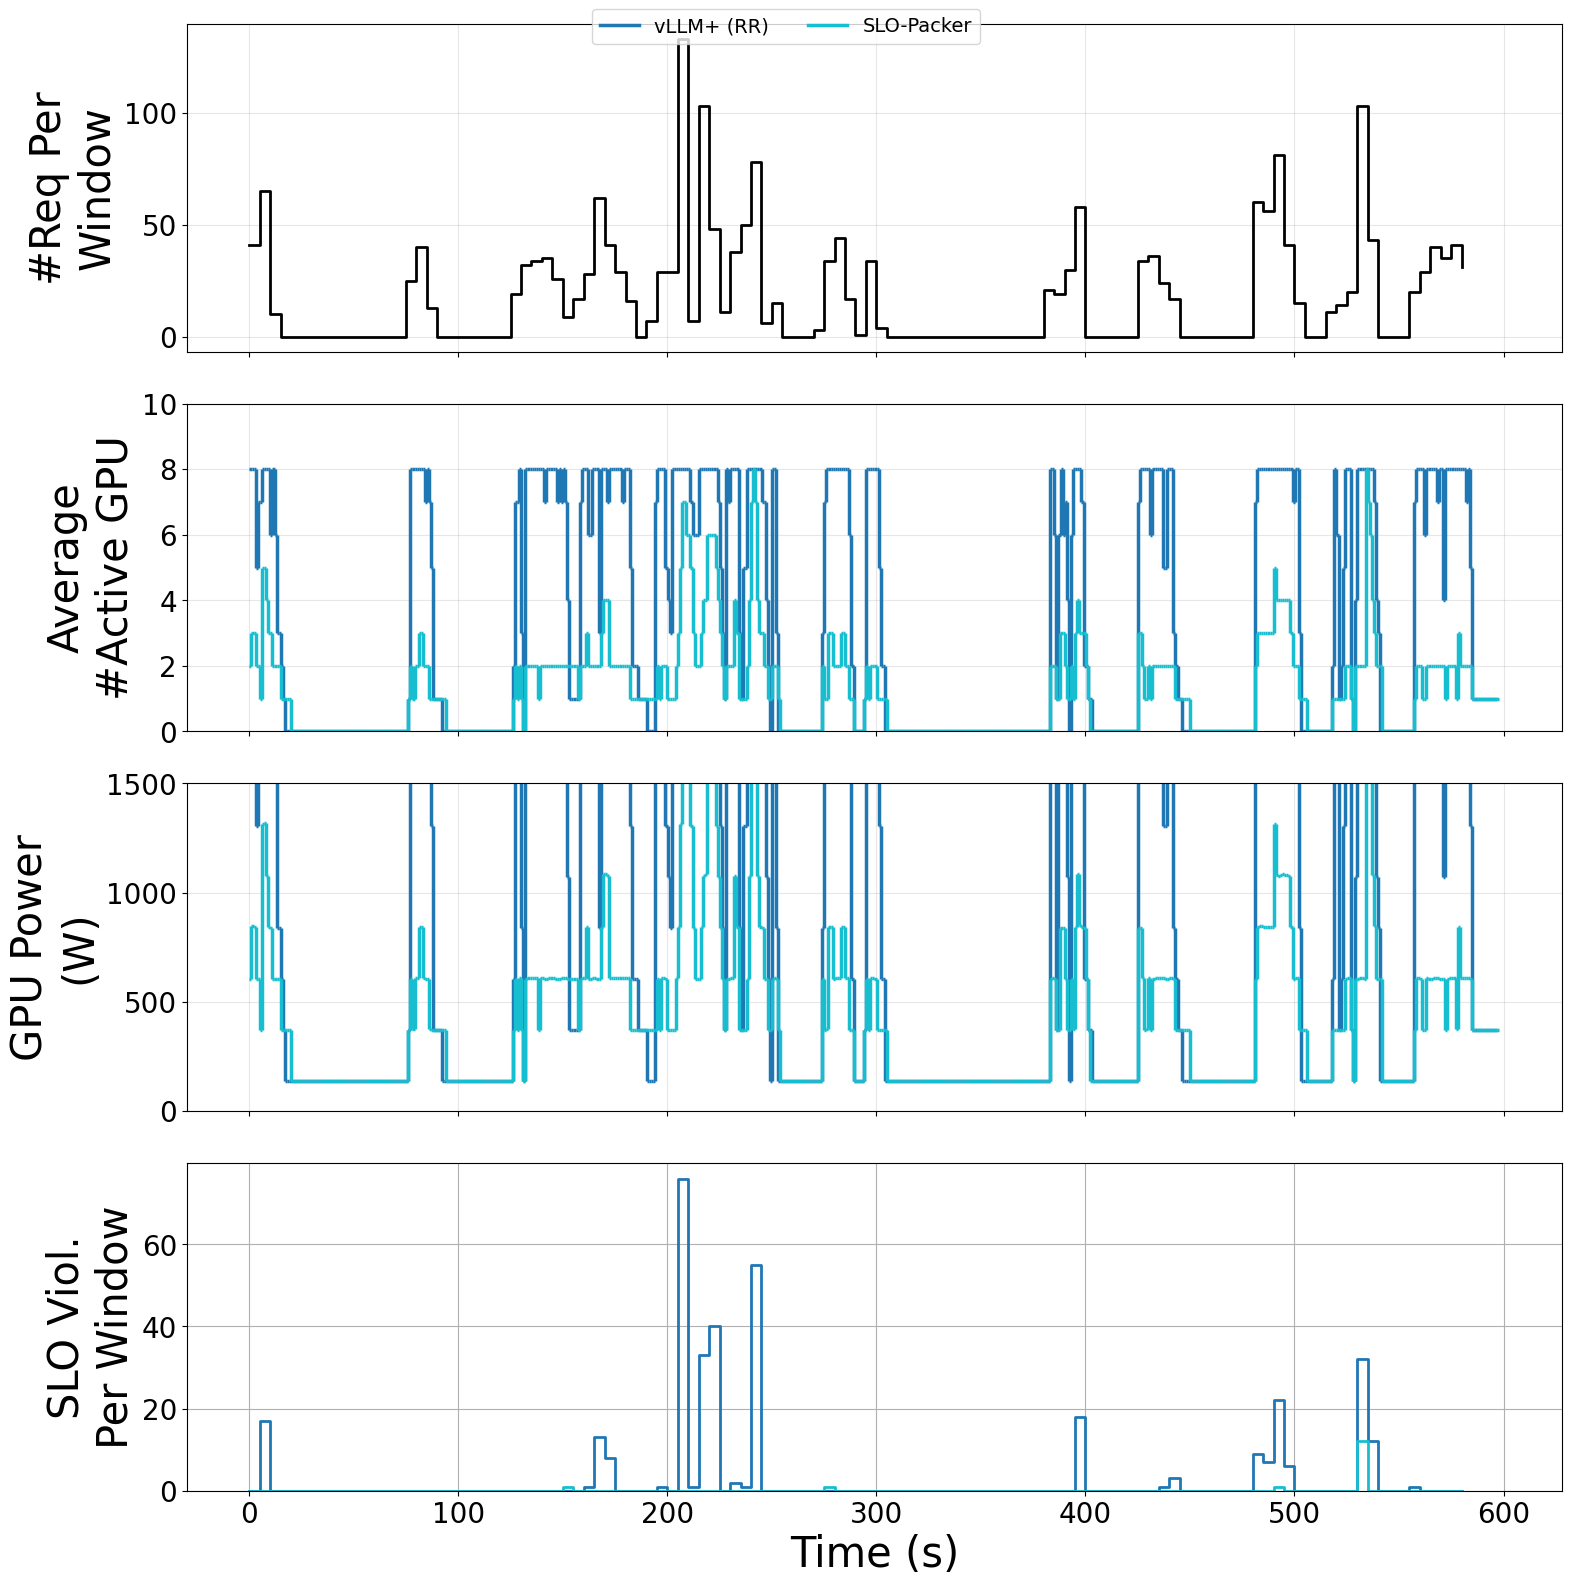

In [ ]:
draw_energy_comparison(
    event_files = [
        # ('SLO-Packer (RR)', 'experiments_emulation_0316/Qwen-7B_constant_azure_code_23:azure_code_23_t1200:1800_arrival_0.0/atfc_round_robin_1.0_8_arrival_5.0_0.05_reject.events.jsonl', 8),
        ('vLLM+ (RR)', 'experiments_emulation_0316/Qwen-7B_constant_azure_code_23:azure_code_23_t1200:1800_arrival_0.0/sarathi+_round_robin_1.0_8_arrival_5.0_0.05_reject.events.jsonl', 8),
        ('SLO-Packer', 'experiments_emulation_0316/Qwen-7B_constant_azure_code_23:azure_code_23_t1200:1800_arrival_0.0/atfc_slosserve_planner_1.0_8_arrival_5.0_0.05_reject.events.jsonl', 8),
        # ('vLLM+ (Load-Aware)', 'experiments_emulation_0316/Qwen-7B_constant_azure_code_23:azure_code_23_t1200:1800_arrival_0.0/sarathi+_llumnix_load_1.0_8_arrival_5.0_0.05_reject.events.jsonl', 8)
    ],
    output_suffix = None,
    line_styles = {},
)

In [5]:
import json
import pandas as pd 
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [6]:
filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/slosserve-edf_slosserve_1.0_6_arrival_5.0_0.05.events.jsonl'
req_filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/slosserve-edf_slosserve_1.0_6_arrival_5.0_0.05.reqs.jsonl'
filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05.events.jsonl'
req_filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05.reqs.jsonl'
file_prefix = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:500_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05'
file_prefix = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:500_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05'
file_prefix = 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_2_0.5_8_arrival_5.0_0.05_reject'
file_prefix = 'experiments_emulation_new/Qwen-7B_constant_azure_code_23:azure_code_23_t0:300_arrival_0.0/atfc_slosserve_planner_1.0_16_arrival_5.0_0.05_reject'
file_prefix = 'experiments_emulation_new/Qwen-7B_constant_azure_code_23:azure_code_23_t100:200_arrival_0.0/atfc_slosserve_planner_1.0_16_arrival_5.0_0.05_reject'
file_prefix = 'experiments_emulation_new/Qwen-7B_constant_azure_code_23:azure_code_23_t800:1000_arrival_0.0/atfc_slosserve_planner_1.0_16_arrival_5.0_0.05_reject'
file_prefix = 'experiments_emulation_0313/Qwen-7B_constant_azure_chat:azure_chat_t0:20_arrival_0.0/atfc_slosserve_planner_1.0_8_arrival_5.0_0.05_reject'
file_prefix = 'experiments_emulation_0313/Qwen-7B_constant_azure_chat:azure_chat_t0:50_arrival_0.0/atfc_slosserve_planner_disagg_1.0_16_arrival_5.0_0.05_reject'
file_prefix = 'experiments_emulation_0313/Qwen-7B_constant_sharegpt_chat:azure_chat_23_t0:100_arrival_0.0/atfc_slosserve_planner_1.0_16_arrival_5.0_0.05_reject'
filename = f'{file_prefix}.events.jsonl'
req_filename = f'{file_prefix}.reqs.jsonl'
with open(filename, 'r') as f:
    data = json.load(f)
with open(req_filename, 'r') as f:
    req_data = json.load(f)

In [7]:
violation_reqs = [req for req in req_data if req['slo_violation'] == 'tpot']
req = violation_reqs[0]
n_tokens = req['prompt_tokens'] + 1
tpot_idx = 0
batches = []
print(req['output_tokens'], len(req['tpot_laxities']))
first_below_zero = None
for sch in req['schedules']:
    n_tokens -= sch['num_scheduled_tokens']
    if n_tokens == 0:
        if tpot_idx >= len(req['tpot_laxities']):
            break
            print('tpot_idx', tpot_idx, len(req['tpot_laxities']), len(req['schedules']))
        laxity = req['tpot_laxities'][tpot_idx]
        if first_below_zero is None and laxity > 0: 
            first_below_zero = (sch['batch_id'], sch['device_id'])
        tpot_idx += 1
        n_tokens = 1
        sch['laxity'] = laxity
        # batches.append((sch['batch_id'], laxity))

len(violation_reqs), first_below_zero, req['req_id'], req['schedules']

IndexError: list index out of range

In [ ]:
batch = next(e for e in data if e['event_type'] == 'planner_sch' and e['extra_args']['batch_id'] == first_below_zero[0]+1 and e['device_id'] == first_below_zero[1])
batch

NameError: name 'data' is not defined

In [8]:
local_admissions = [e for e in data if e['event_type'] == 'local_admission']
global_admissions = [e for e in data if e['event_type'] == 'global_admission']
len(local_admissions), len(global_admissions), local_admissions[0], global_admissions[0]

IndexError: list index out of range

In [9]:
reqs_to_events = defaultdict(list)
for global_adm in global_admissions:
    for req_id, state in global_adm['extra_args']['state'].items():
        is_new_req, is_acc, n_computed_tokens, input_length, ddl, max_tokens, arrival_time = state
        if is_new_req and is_acc:
            reqs_to_events[req_id].append(('global_adm', global_adm['timestamp'], global_adm['device_id'], global_adm, is_acc))
for local_adm in local_admissions:
    for req_id, state in local_adm['extra_args']['state'].items():
        is_new_req, is_acc, n_computed_tokens, input_length, ddl, max_tokens, arrival_time = state
        if is_new_req:
            reqs_to_events[req_id].append(('local_adm', local_adm['timestamp'], local_adm['device_id'], local_adm, is_acc))
for k in reqs_to_events:
    reqs_to_events[k] = sorted(reqs_to_events[k], key = lambda x: x[1])
lens = (len(x) for x in reqs_to_events.values())
pd.Series(lens).describe(), list(reqs_to_events.values())[0]

(count    264.000000
 mean       1.026515
 std        0.160967
 min        1.000000
 25%        1.000000
 50%        1.000000
 75%        1.000000
 max        2.000000
 dtype: float64,
 [('global_adm',
   0.07770085334777832,
   0,
   {'event_type': 'global_admission',
    'device_id': 0,
    'timestamp': 0.07770085334777832,
    'extra_args': {'is_feasible': True,
     'now': 1773806711.5711792,
     'state': {'4020fc66-6769-4b39-8eac-3a66028b3b6d': [True,
       True,
       0,
       962,
       0.1803135871887207,
       1124,
       -0.010934591293334961]}}},
   True)])

In [10]:
pairs = []
errs = []
matches = []
pair = None 
for req, events in reqs_to_events.items():
    for idx in range(0, len(events), 2):
        if idx + 1 >= len(events): continue
        if events[idx][0] == 'global_adm' and events[idx+1][0] == 'local_adm':
            pairs.append((req, events[idx:idx+2]))
            if req == '67' and pair is None: pair = events[idx:idx+2]
        else:
            errs.append((events[idx][0], events[idx+1][0]))
assert(not len(errs))
acc_pairs = [(x[1][0][-1], x[1][1][-1]) for x in pairs]
pairs[0], Counter(acc_pairs), pair

AssertionError: 

(0,
 0,
 0,
 count       0
 unique      0
 top       NaN
 freq      NaN
 dtype: object,
 [])

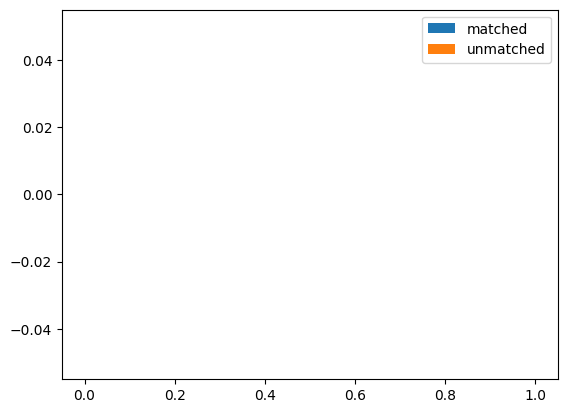

In [11]:
# Hypothesis 1: the batch time is staled
matched_pairs = [p for p in pairs if p[1][1][-1]]
unmatched_pairs = [p for p in pairs if not p[1][1][-1]]
matched_global_staleness = [(global_adm[-2]['extra_args']['now']- local_adm[-2]['extra_args']['now']) for req, (global_adm, local_adm) in matched_pairs]
unmatched_global_staleness = [(global_adm[-2]['extra_args']['now']- local_adm[-2]['extra_args']['now']) for  req, (global_adm, local_adm) in unmatched_pairs]
pd.Series(matched_global_staleness).describe()
pd.Series(unmatched_global_staleness).describe()
plt.hist(matched_global_staleness, label = 'matched')
plt.hist(unmatched_global_staleness, label = 'unmatched')
plt.legend()
len(matched_global_staleness), len(unmatched_global_staleness), sum(x < -0.02 for x in unmatched_global_staleness), pd.Series(unmatched_global_staleness).describe(), [x[0] for x in unmatched_pairs]


In [12]:
req_id, (global_adm, local_adm) = unmatched_pairs[0]
print('req', req_id, 'device_id', global_adm[3]['device_id'])
# is_new_req, is_acc, n_computed_tokens, input_length, ddl, max_tokens, arrival_time 
def f(adm, tag):
    lst = sorted((list(adm[3]['extra_args']['state'].items())), key = lambda x: int(x[0]))
    return [[int(k), tag] + v for k, v in lst]
rows = f(global_adm, 'global') + f(local_adm, 'local')
df = pd.DataFrame(
    rows,
    columns=[
        'req_id', 'adm',
        'is_new_req', 'is_acc', 'n_computed_tokens',
        'input_length', 'ddl', 'max_tokens', 'arrival_time'
    ]
)
df = df.set_index(['req_id', 'adm'])
print('staleness', global_adm[3]['extra_args']['now']- local_adm[3]['extra_args']['now'])
print(global_adm[3]['extra_args']['is_feasible'], local_adm[3]['extra_args']['is_feasible'])
df.sort_index()

IndexError: list index out of range

In [13]:
above_zero_ratio = lambda lst: sum(x>0 for x in lst) / len(lst)
slo_violation_reqs = [(above_zero_ratio(req['tpot_laxities']), req) for req in req_data if req['slo_violation'] == 'tpot']
slo_violation_reqs.sort(key = lambda x: x[0], reverse = True)
slo_violation_reqs_high = [x for x in slo_violation_reqs if x[0] > 0.10]
output_lengths = [x[1]['output_tokens'] for x in slo_violation_reqs_high]
pd.Series((x[0] for x in slo_violation_reqs)).describe(), slo_violation_reqs[0], pd.Series(output_lengths).describe(), len(slo_violation_reqs_high)
#, slo_violation_reqs_high

IndexError: list index out of range

In [14]:
finishes = [x['scheduling_overhead'] for x in data if x['event_type'] == 'finish' and x['finish_reason'] == 'rejected-arrival']
pd.Series(finishes).describe(percentiles = [0.50,0.80,0.90,0.95,0.98,0.99])


count    15.000000
mean      0.003954
std       0.001948
min       0.001819
50%       0.002981
80%       0.004705
90%       0.006128
95%       0.007394
98%       0.008503
99%       0.008872
max       0.009242
dtype: float64

In [15]:
batches = [x for x in data if x['event_type'] == 'batch']

In [16]:
ts = [b['extra_args']['to_finish'] - b['extra_args']['to_est_finish'] for b in batches]

pd.Series(ts).describe(percentiles = [0.50,0.80,0.90,0.95,0.98,0.99])

count    10212.000000
mean         0.000056
std          0.000311
min         -0.001107
50%         -0.000027
80%          0.000401
90%          0.000500
95%          0.000583
98%          0.000628
99%          0.000644
max          0.001425
dtype: float64

In [17]:
batches = [(b['between_batch_time'] - b['estimated_time'], b) for b in batches]

In [18]:
batches = sorted(batches, reverse = True, key = lambda x: x[0])

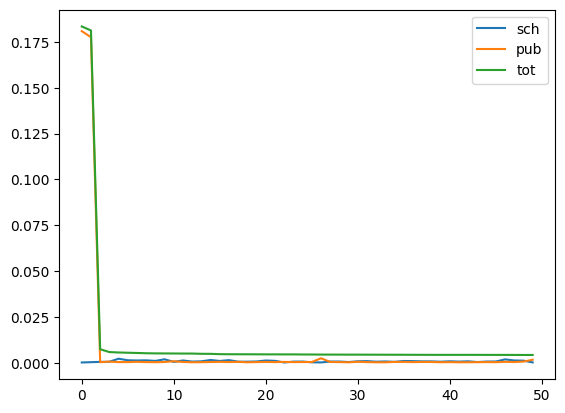

In [19]:
top_batches = batches[:50]
scheduling_overheads = [b[1]['scheduling_overhead'] for b in top_batches]
publish_overheads = [b[1]['publish_overhead'] for b in top_batches]
total_overhead = [b[0] for b in top_batches]
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for label, overheads in [
    ('sch', scheduling_overheads),
    ('pub', publish_overheads),
    ('tot', total_overhead)
]:
    ax.plot(overheads, label = label)
ax.legend()

In [20]:
[x['event_type'] for x in req_data[0]['events']], req_data[0]['events'], req_data[0]['slo_violation']

(['global_arrival',
  'arrival-router',
  'router_decision',
  'dispatch',
  'arrival',
  'add_request_sch',
  'add_request',
  'admitted',
  'finish'],
 [{'event_type': 'global_arrival',
   'timestamp': 0.016036510467529297,
   'device_id': 0,
   'extra_args': {},
   'request_id': '0'},
  {'event_type': 'arrival-router',
   'timestamp': 0.0666959285736084,
   'device_id': -1,
   'extra_args': {},
   'request_id': '0',
   'prefill_ddl': 0.25794410705566406,
   'profit': 1.0,
   'prompt_tokens': 962,
   'max_tokens': 272,
   'zero_load_ttft': 0.02824962},
  {'event_type': 'router_decision',
   'timestamp': 0.07132959365844727,
   'device_id': -1,
   'extra_args': {'routing_iter': 1},
   'request_id': '0',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'dispatch',
   'timestamp': 0.07795929908752441,
   'device_id': -1,
   'extra_args': {},
   'type': 'both',
   'request_id': '0',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'arrival',
  

In [21]:
req_data[0].keys()

dict_keys(['req_id', 'prompt_tokens', 'num_cached_tokens', 'arrival_time', 'engine_arrival_time', 'profit', 'schedules', 'events', 'timestamps', 'output_tokens', 'prefill_device_id', 'decode_device_id', 'cache_hit_rate', 'prefill_ddl', 'ttft_normalized_laxity', 'tpot_laxities', 'expected_finish_time', 'finish_reason', 'slo_violation', 'kv_xfer_delay', 'zero_load_ttft'])

In [22]:
from collections import defaultdict
import pandas as pd

In [23]:
slo_violated_to_arrive_finish_pairs = defaultdict(list)
slo_violated_to_finish_rescheduling_pairs = defaultdict(list)
slo_attained_to_arrive_finish_pairs = defaultdict(list)

In [24]:
violation_reasons = defaultdict(int)
for req in req_data:

    violation_reasons[req['slo_violation']] += 1
    for eid, e in enumerate(req['events']):
        if e['event_type'] == 'arrival':
            i = eid + 1
            while i < len(req['events']) and req['events'][i]['event_type'] != 'finish':
                i += 1 
            if not i < len(req['events']): continue
            next_e = req['events'][i]
            # assert next_e['event_type'] == 'finish'
            if req['slo_violation'] != 'none':
                slo_violated_to_arrive_finish_pairs[req['req_id']].append((e['timestamp'], next_e['timestamp'], e['device_id']))
            else:
                slo_attained_to_arrive_finish_pairs[req['req_id']].append((e['timestamp'], next_e['timestamp'], e['device_id']))
        if e['event_type'] == 'finish' and next_e['event_type'] == 'rescheduling':
            slo_violated_to_finish_rescheduling_pairs[req['req_id']].append(next_e['timestamp'] - e['timestamp'])
violation_reasons

defaultdict(int, {'none': 253, 'router_rejection': 115, 'ttft': 3})

In [25]:
reqs = [req for req in req_data if req['slo_violation'] is None]
reqs[2]

IndexError: list index out of range

In [26]:
finish_events = sum([[e for e in req['events'] if e['event_type'] == 'finish'] for req in req_data], start = [])


In [27]:
reasons = [x['finish_reason'] for x in finish_events]
from collections import Counter
Counter(reasons)

Counter({'length': 256, 'router_rejection': 115, 'rejected-arrival': 15})

In [28]:
rejected_reqs = [req for req in req_data if req['finish_reason'] == 'router_rejection']
prompt_tokens = [req['prompt_tokens'] for req in rejected_reqs]
all_prompt_tokens = [req['prompt_tokens'] for req in req_data]

In [29]:
top_batches = batches[:10]

n_overlap = 0
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    is_overlap = False
    for arrive, finish, device in arrive_finish_pairs:
        for _, b in top_batches:
            if (b['device_id'] == device) and (arrive < b['timestamp'] < finish):
                is_overlap = True 
    n_overlap += is_overlap
n_overlap / len(slo_violated_to_arrive_finish_pairs), n_overlap, len(slo_violated_to_arrive_finish_pairs)

(0.09090909090909091, 1, 11)

(count    3.000000
 mean     0.011596
 std      0.001586
 min      0.009813
 50%      0.012122
 60%      0.012268
 70%      0.012414
 80%      0.012560
 90%      0.012705
 95%      0.012778
 99%      0.012837
 max      0.012851
 dtype: float64,
 (array([1., 0., 0., 0., 0., 0., 0., 1., 0., 1.]),
  array([0.00981334, 0.01011713, 0.01042092, 0.01072472, 0.01102851,
         0.0113323 , 0.0116361 , 0.01193989, 0.01224368, 0.01254748,
         0.01285127]),
  <BarContainer object of 10 artists>))

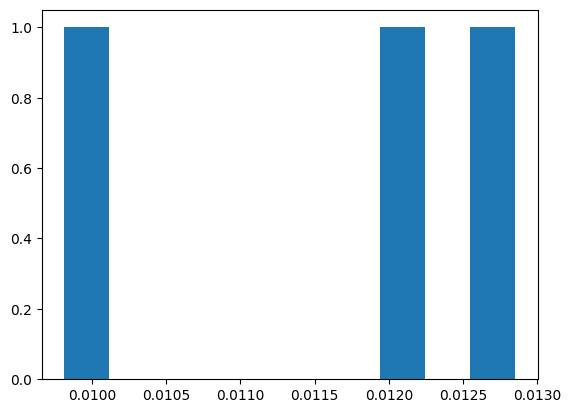

In [30]:
violated_reqs = [req for req in req_data if req['slo_violation'] == 'ttft']
laxities = [x['ttft_normalized_laxity'] for x in violated_reqs]
pd.Series(laxities).describe(percentiles=[0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]), plt.hist(laxities)

In [31]:
rejected_reqs = [req for req in req_data if 'ttft' in req['slo_violation']]
results = []
for req in rejected_reqs:
    breakdown = []
    acc = 0
    for e, next_e in zip(req['events'][1:], req['events'][2:]):
        gap = round(next_e['timestamp'] - e['timestamp'], 6)
        breakdown.append((e['event_type'] + '->' + next_e['event_type'], gap, acc + gap))
        acc += gap
    results.append((req['req_id'], req['prefill_ddl'] - req['arrival_time'], req['prompt_tokens'], breakdown))
results[0]
# TODO: visulize this for each request by having a bar graph, each entry is a request with a breakdown by time categories; also, add a mark for each request's req['prefill_ddl'] - req['arrival_time']

('97',
 0.19569730758666992,
 3174,
 [('router_decision->arrival-router', 0.004886, 0.004886),
  ('arrival-router->dispatch', 0.003738, 0.008624),
  ('dispatch->arrival', 0.005946, 0.01457),
  ('arrival->add_request_sch', 4.3e-05, 0.014613),
  ('add_request_sch->add_request', 8.9e-05, 0.014702),
  ('add_request->admitted', 0.002508, 0.01721),
  ('admitted->finish', 6.836235, 6.853445000000001)])

In [32]:
from collections import Counter
violation_reasons = [req['slo_violation'] for req in req_data]
Counter(violation_reasons)

Counter({'none': 253, 'router_rejection': 115, 'ttft': 3})

In [33]:
slo_violate_reqs = [req for req in req_data if req['slo_violation'] == 'router_rejection']
results = []
for req in slo_violate_reqs:
    prompt_tokens = req['prompt_tokens']
    breakdown = []
    acc = 0
    last_timestamp = None
    for e, next_e in zip(req['events'][1:], req['events'][2:]):
        gap = round(next_e['timestamp'] - e['timestamp'], 6)
        last_timestamp = next_e['timestamp']
        breakdown.append((e['event_type'] + '->' + next_e['event_type'], gap, acc + gap))
        acc += gap
        # if next_e['event_type'] == 'arrival' and next_e['device_id'] == req['prefill_device_id']:
        #     break
    if len(req['schedules']):
        first_sch = req['schedules'][0]
        batch_events = [('B0_start', first_sch['timestamp'] - first_sch['elapsed'])]
        key = (first_sch['batch_id'] - 1, req['prefill_device_id'])
        if key in batches:
            last_batch = batches[key]
            batch_events.extend([
                ('LB-start', last_batch['timestamp'] - last_batch['elapsed']),
                ('LB-schedule', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_schedule']),
                ('LB-launch', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_launch']),
                ('LB-finish', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_finish']),
                ('LB-est_finish', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_est_finish']),
            ])
    
        batch_events = sorted(batch_events, key = lambda x: x[1])
        last_event = 'arrival'
        for event_name, timestamp in batch_events:
            if timestamp < last_timestamp: continue
            gap = timestamp - last_timestamp
            breakdown.append((f'{last_event} -> {event_name}', gap, acc + gap))
            last_event = event_name 
            last_timestamp = timestamp
        
        # gap = bid2batch_start_time[(req['schedules'][0]['batch_id'], req['prefill_device_id'])] - last_timestamp
        # last_timestamp = bid2batch_start_time[(req['schedules'][0]['batch_id'], req['prefill_device_id'])]
        # breakdown.append((f'{last_event} -> B0_start', gap, gap + acc))
        # acc += gap 
        # last_event = 'B0_start'
        
        for bid, b in enumerate(req['schedules']):
            gap = b['timestamp'] - last_timestamp
            last_timestamp = b['timestamp']
            breakdown.append((f'{last_event}->B{bid}', gap, acc + gap))
            acc += gap
            last_event = f'B{bid}'
            prompt_tokens -= b['num_scheduled_tokens']
            if prompt_tokens <= 0: break
    results.append((req['req_id'], req['prefill_ddl'] - req['arrival_time'], req['prompt_tokens'], breakdown))
results[0]

('1',
 0.14574599266052246,
 2413,
 [('arrival-router->temporal_rej', 0.007157, 0.007157),
  ('temporal_rej->temporal_rej', 0.005905, 0.013062),
  ('temporal_rej->temporal_rej', 0.006781, 0.019843),
  ('temporal_rej->temporal_rej', 0.006656, 0.026498999999999998),
  ('temporal_rej->temporal_rej', 0.006626, 0.033125),
  ('temporal_rej->temporal_rej', 0.006767, 0.039892000000000004),
  ('temporal_rej->temporal_rej', 0.006823, 0.046715000000000007),
  ('temporal_rej->temporal_rej', 0.006709, 0.053424000000000006),
  ('temporal_rej->temporal_rej', 0.00695, 0.060374000000000004),
  ('temporal_rej->temporal_rej', 0.006469, 0.066843),
  ('temporal_rej->temporal_rej', 0.006695, 0.073538),
  ('temporal_rej->temporal_rej', 0.006889, 0.08042700000000001),
  ('temporal_rej->temporal_rej', 0.006381, 0.08680800000000001),
  ('temporal_rej->temporal_rej', 0.006799, 0.09360700000000001),
  ('temporal_rej->temporal_rej', 0.006697, 0.100304),
  ('temporal_rej->temporal_rej', 0.006675, 0.106979),
  ('tem

In [34]:
n_tmp_rejs = [len([e for e in req['events'] if e['event_type'] == 'temporal_rej'] ) for req in slo_violate_reqs]
pd.Series(n_tmp_rejs).describe()

count    115.000000
mean      27.939130
std        8.941611
min       14.000000
25%       22.000000
50%       26.000000
75%       31.500000
max       64.000000
dtype: float64

In [35]:
temp_rej_iters = sum([([(e['extra_args']['routing_iter'], e['extra_args']['prefill_id']) for e in req['events'] if e['event_type'] == 'temporal_rej'] ) for req in slo_violate_reqs], start = [])
panic_last_server = sum([x[1] == 15 for x in temp_rej_iters])
from collections import Counter 
Counter(temp_rej_iters), len(temp_rej_iters), panic_last_server

(Counter({(1038, -1): 3,
          (1039, -1): 3,
          (1040, -1): 3,
          (1041, -1): 3,
          (1042, -1): 3,
          (1043, -1): 3,
          (1044, -1): 3,
          (1045, -1): 3,
          (1046, -1): 3,
          (1047, -1): 3,
          (1048, -1): 3,
          (1049, -1): 3,
          (1076, -1): 3,
          (1077, -1): 3,
          (1078, -1): 3,
          (1079, -1): 3,
          (1080, -1): 3,
          (1081, -1): 3,
          (1087, -1): 3,
          (1088, -1): 3,
          (1089, -1): 3,
          (1090, -1): 3,
          (1091, -1): 3,
          (1092, -1): 3,
          (1093, -1): 3,
          (1094, -1): 3,
          (1095, -1): 3,
          (1390, -1): 3,
          (1391, -1): 3,
          (1392, -1): 3,
          (1393, -1): 3,
          (1394, -1): 3,
          (1395, -1): 3,
          (1396, -1): 3,
          (1397, -1): 3,
          (1398, -1): 3,
          (1399, -1): 3,
          (1400, -1): 3,
          (1401, -1): 3,
          (1402, -1): 3,


In [39]:
req = slo_violate_reqs[0]
sum([e['event_type'] == 'temporal_rej' for e in req['events']]), req

(21,
 {'req_id': '1',
  'prompt_tokens': 2413,
  'num_cached_tokens': 0,
  'arrival_time': 4.347229242324829,
  'engine_arrival_time': -1.0,
  'profit': 0,
  'schedules': [],
  'events': [{'event_type': 'global_arrival',
    'timestamp': 4.321035385131836,
    'device_id': 0,
    'extra_args': {},
    'request_id': '1'},
   {'event_type': 'arrival-router',
    'timestamp': 4.347229242324829,
    'device_id': -1,
    'extra_args': {},
    'request_id': '1',
    'prefill_ddl': 4.492975234985352,
    'profit': 1.0,
    'prompt_tokens': 2413,
    'max_tokens': 100,
    'zero_load_ttft': 0.019149180000000002},
   {'event_type': 'temporal_rej',
    'timestamp': 4.354385852813721,
    'device_id': -1,
    'extra_args': {'routing_overhead': 0.0074274539947509766,
     'waiting_time': 0.0055277347564697266,
     'window_size': 0.005,
     'to_logging': 0.0074312686920166016,
     'to_launch': 0.007432222366333008,
     'to_get_stats': 0.007432699203491211,
     'to_prefill_ddl': -0.138589382171

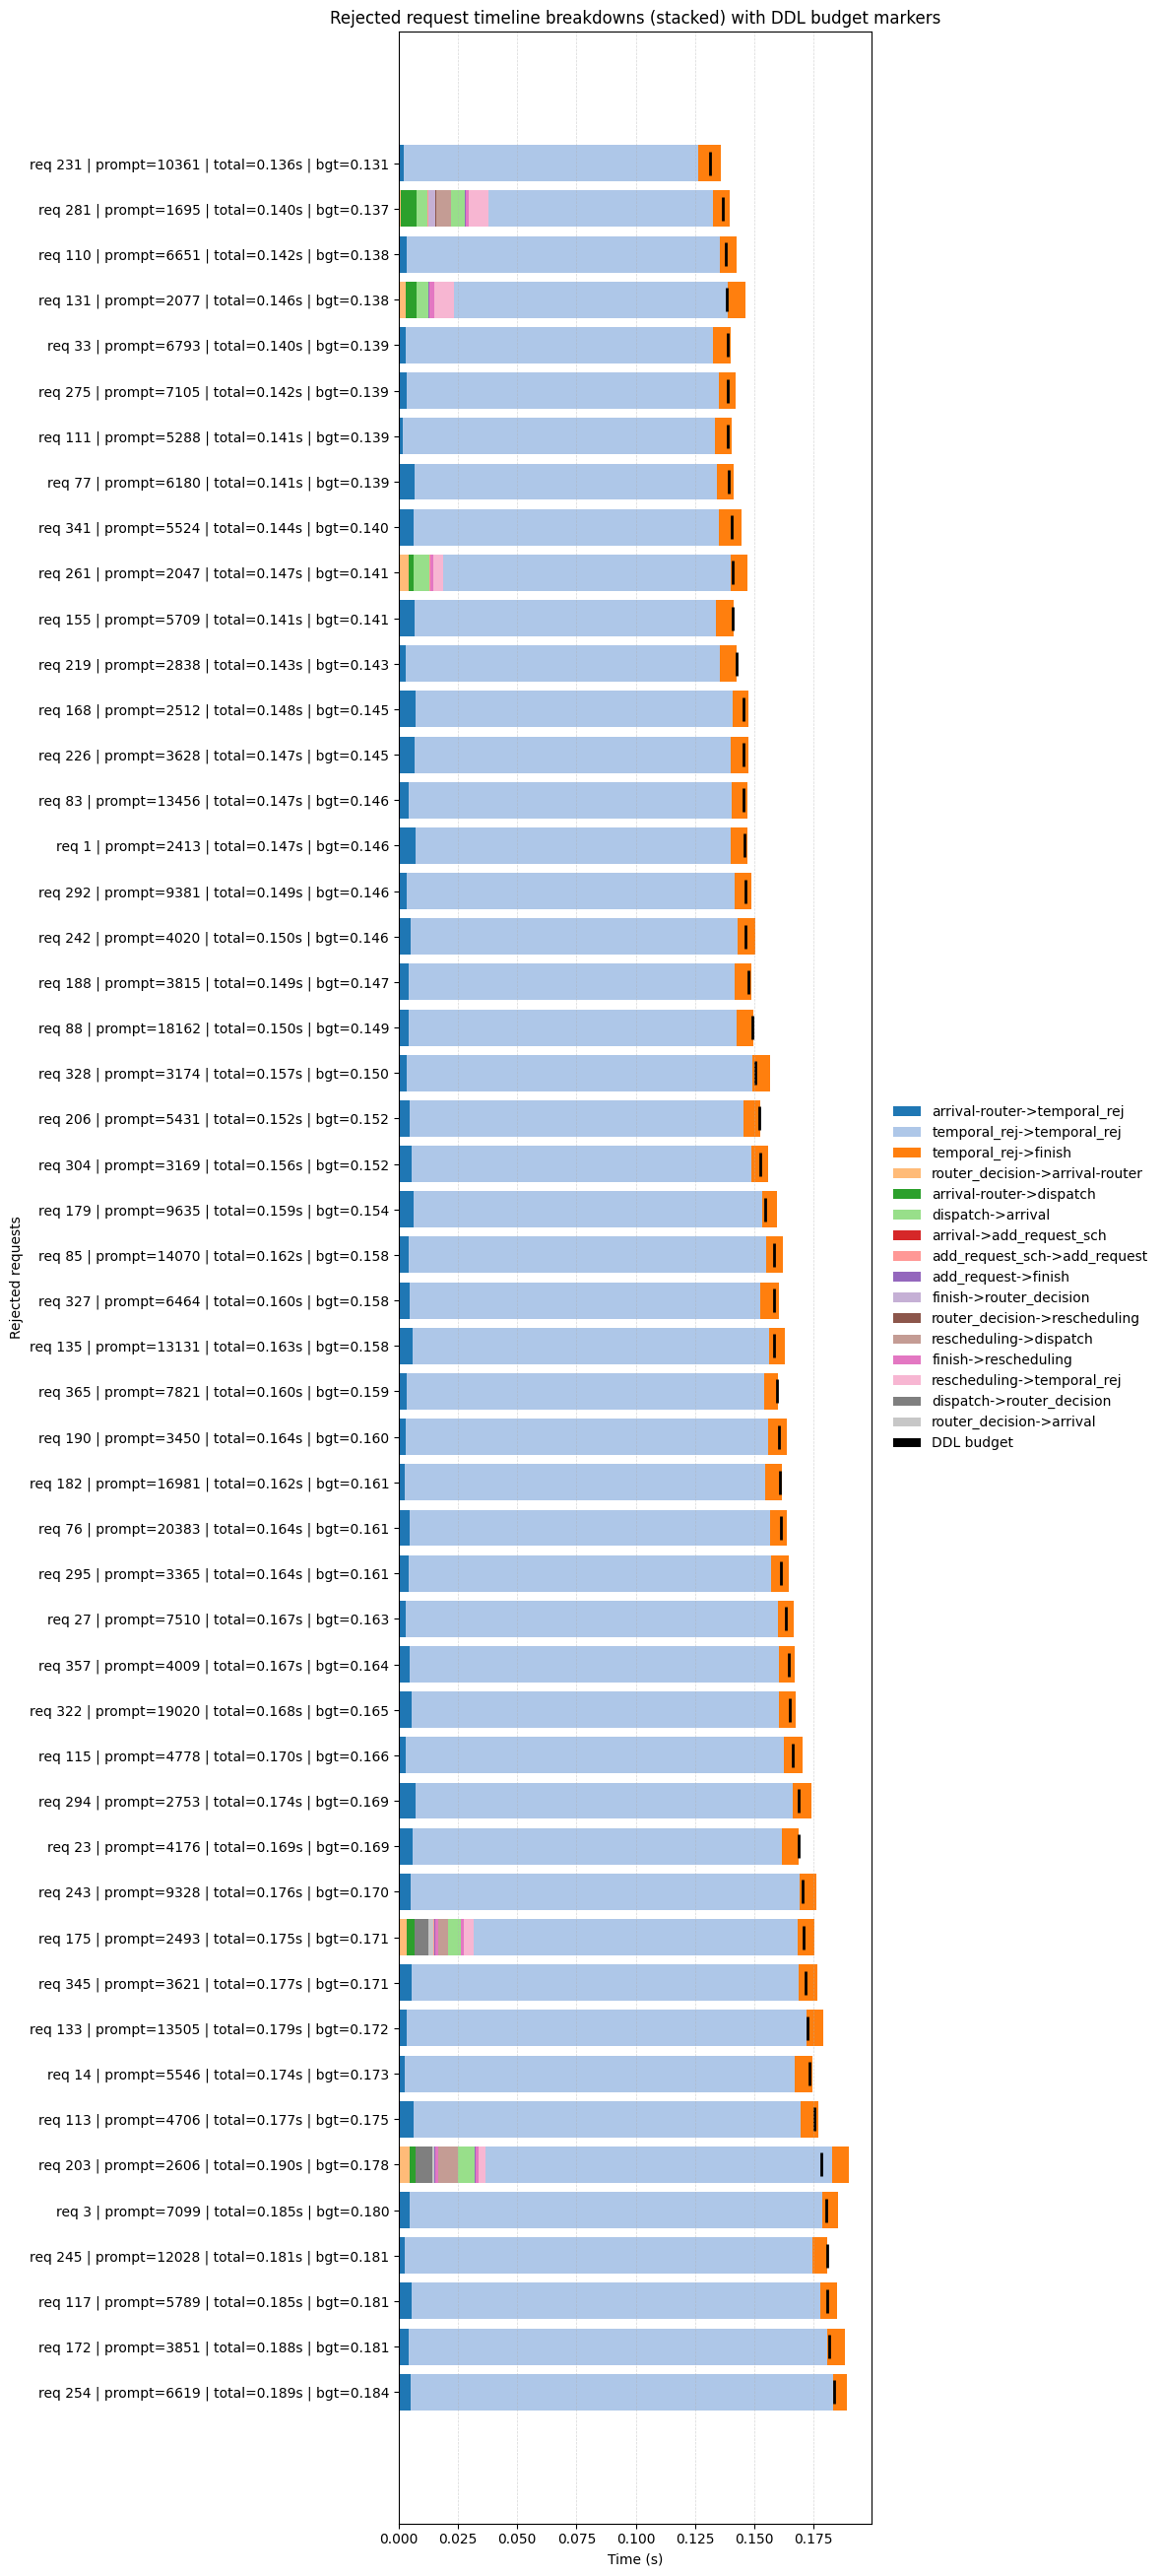

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_reject_breakdowns(results, max_reqs=None, sort_by="ddl", title=None):
    """
    Stacked horizontal bars per request:
      - each segment = one entry in breakdown (keeps duplicates)
      - vertical marker = ddl_budget

    results item format:
      (req_id, ddl_budget, prompt_tokens, breakdown)
      breakdown = [(label, gap, cumulative), ...]
    """
    if not results:
        raise ValueError("results is empty")

    # Sort
    if sort_by == "ddl":
        results = sorted(results, key=lambda x: x[1])   # ddl_budget
    elif sort_by == "total":
        results = sorted(results, key=lambda x: sum(seg[1] for seg in x[3]))
    elif sort_by == "prompt":
        results = sorted(results, key=lambda x: x[2])

    if max_reqs is not None:
        results = results[:max_reqs]

    n = len(results)
    y = list(range(n))

    # Stable unique labels for color mapping + legend
    labels = []
    seen = set()
    for _, _, _, breakdown in results:
        for label, _, _ in breakdown:
            label = label.replace("_mux", "mux")
            if label not in seen:
                seen.add(label)
                labels.append(label)

    cmap = plt.get_cmap("tab20")
    color_of = {lab: cmap(i % 20) for i, lab in enumerate(labels)}

    fig_h = max(4, 0.35 * n)
    fig, ax = plt.subplots(figsize=(12, fig_h * 1.5))

    ddl_budgets, prompts, totals, req_ids = [], [], [], []

    # Draw each request from raw breakdown sequence (duplicates preserved)
    for i, (req_id, ddl_budget, prompt_tokens, breakdown) in enumerate(results):
        left = 0.0
        total = 0.0
        for label, gap, _ in breakdown:
            label = label.replace("_mux", "mux")
            gap = float(gap)
            ax.barh(i, gap, left=left, color=color_of[label])
            left += gap
            total += gap

        ddl_budgets.append(float(ddl_budget))
        prompts.append(int(prompt_tokens))
        totals.append(total)
        req_ids.append(req_id)

    # DDL markers
    ax.scatter(ddl_budgets, y, marker="|", s=300, color="black", linewidths=2, label="DDL budget")

    ylabels = [
        f"req {req_ids[i]} | prompt={prompts[i]} | total={totals[i]:.3f}s | bgt={ddl_budgets[i]:.3f}"
        for i in range(n)
    ]
    ax.set_yticks(y)
    ax.set_yticklabels(ylabels)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Rejected requests")
    ax.invert_yaxis()

    if title is None:
        title = "Rejected request timeline breakdowns (stacked) with DDL budget markers"
    ax.set_title(title)

    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

    # Clean legend (one entry per label + DDL)
    legend_handles = [Patch(facecolor=color_of[lab], label=lab) for lab in labels]
    legend_handles.append(Patch(facecolor="black", label="DDL budget"))
    ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.tight_layout()
    return fig, ax


# Example usage:
fig, ax = plot_reject_breakdowns(results, max_reqs=50, sort_by="ddl")
plt.show()

Most time-consuming: ['temporal_rej->temporal_rej', 'temporal_rej->finish', 'arrival-router->temporal_rej', 'dispatch->arrival', 'rescheduling->temporal_rej']


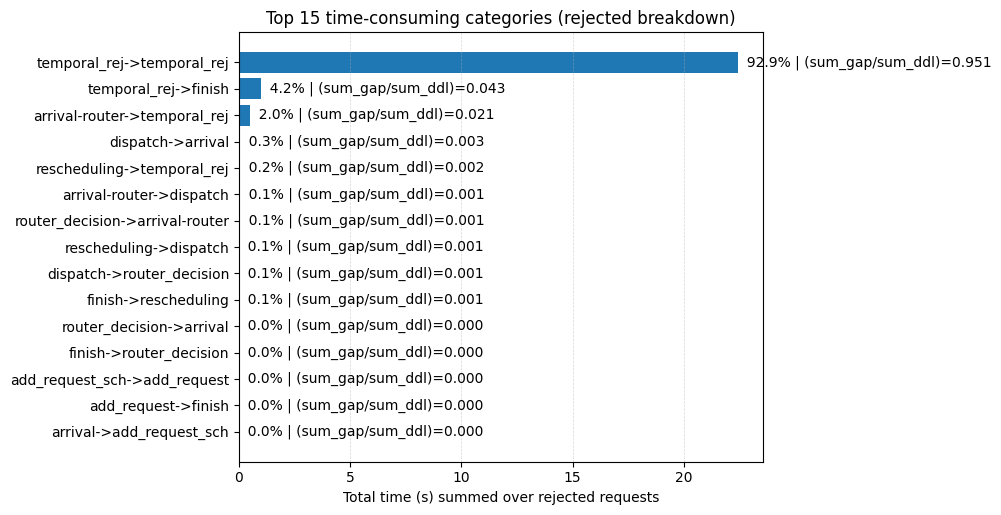

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_reject_time_by_category(results, *, normalize_labels=True, topk=20, make_plot=True):
    """
    Aggregate breakdown time by category label across all requests.

    Returns:
      stats: dict with
        - total_gap_by_label: {label: seconds}
        - share_by_label: {label: fraction_of_total}
        - norm_by_sumddl: {label: (sum_gap_label / sum_ddl_all)}   # label's contribution per 1s deadline
        - norm_mean_per_req: {label: mean_over_reqs(gap_label_i / ddl_i)}   # optional, per-request normalized mean
        - totals: summary numbers
    """
    if not results:
        raise ValueError("results is empty")

    def norm_label(lab: str) -> str:
        if not normalize_labels:
            return lab
        return lab.replace("_mux", "mux")

    # Aggregators
    total_gap_by_label = {}
    per_req_norm_accum = {}   # label -> list of (gap_label_i / ddl_i)
    sum_ddl = 0.0
    sum_total_gap = 0.0

    for req_id, ddl_budget, prompt_tokens, breakdown in results:
        ddl = float(ddl_budget)
        if ddl > 0:
            sum_ddl += ddl

        # accumulate per request label gaps (so we can do mean per-request normalization)
        gap_by_label_this_req = {}

        for label, gap, cumulative in breakdown:
            label = norm_label(label)
            gap = float(gap)

            total_gap_by_label[label] = total_gap_by_label.get(label, 0.0) + gap
            gap_by_label_this_req[label] = gap_by_label_this_req.get(label, 0.0) + gap
            sum_total_gap += gap

        if ddl > 0:
            for label, g in gap_by_label_this_req.items():
                per_req_norm_accum.setdefault(label, []).append(g / ddl)

    # Shares
    share_by_label = {}
    if sum_total_gap > 0:
        for label, g in total_gap_by_label.items():
            share_by_label[label] = g / sum_total_gap

    # Normalization: category contribution per second of deadline budget (aggregated)
    norm_by_sumddl = {}
    if sum_ddl > 0:
        for label, g in total_gap_by_label.items():
            norm_by_sumddl[label] = g / sum_ddl
    else:
        for label in total_gap_by_label:
            norm_by_sumddl[label] = np.nan

    # Mean per-request normalized contribution (optional alternative normalization)
    norm_mean_per_req = {}
    for label, arr in per_req_norm_accum.items():
        norm_mean_per_req[label] = float(np.mean(arr)) if arr else np.nan

    # Sort labels by total time descending
    labels_sorted = sorted(total_gap_by_label.keys(), key=lambda l: total_gap_by_label[l], reverse=True)

    stats = {
        "total_gap_by_label": total_gap_by_label,
        "share_by_label": share_by_label,
        "norm_by_sumddl": norm_by_sumddl,
        "norm_mean_per_req": norm_mean_per_req,
        "totals": {
            "sum_total_gap": float(sum_total_gap),
            "sum_ddl": float(sum_ddl),
            "n_requests": len(results),
            "n_labels": len(total_gap_by_label),
        },
        "labels_sorted": labels_sorted,
    }

    if make_plot:
        top = labels_sorted[:topk]
        xs = [total_gap_by_label[l] for l in top]

        fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(top))))
        ax.barh(top[::-1], xs[::-1])  # largest on top visually
        ax.set_xlabel("Total time (s) summed over rejected requests")
        ax.set_title(f"Top {len(top)} time-consuming categories (rejected breakdown)")
        ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

        # Annotate with share + normalized-by-deadline
        for i, lab in enumerate(top[::-1]):
            g = total_gap_by_label[lab]
            sh = share_by_label.get(lab, 0.0)
            n1 = norm_by_sumddl.get(lab, np.nan)
            ax.text(g, i, f"  {sh*100:.1f}% | (sum_gap/sum_ddl)={n1:.3f}", va="center")

        plt.tight_layout()

    return stats


# Example:
stats = analyze_reject_time_by_category(results, topk=15, make_plot=True)
print("Most time-consuming:", stats["labels_sorted"][:5])

(count    13617.000000
 mean         2.638099
 std          4.275272
 min          1.000000
 25%          1.000000
 50%          1.000000
 75%          2.000000
 max         44.000000
 dtype: float64,
 count    1691.000000
 mean        6.852750
 std         6.149438
 min         1.000000
 25%         1.000000
 50%         6.000000
 75%        12.000000
 max        40.000000
 dtype: float64)

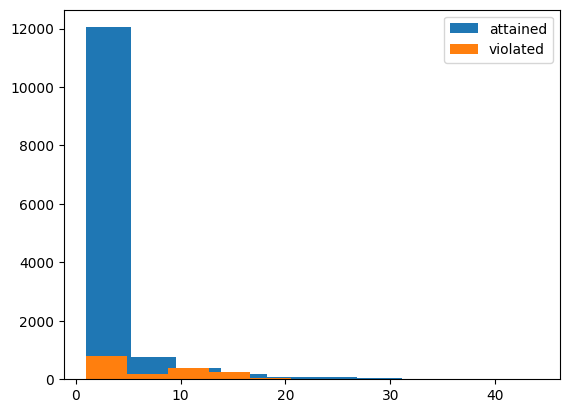

In [27]:
attained_lens = [len(x) for x in slo_attained_to_arrive_finish_pairs.values()]
violated_lens = [len(x) for x in slo_violated_to_arrive_finish_pairs.values()]
fig, ax = plt.subplots()
ax.hist(attained_lens, label = 'attained')
ax.hist(violated_lens, label = 'violated')
ax.legend()
pd.Series(attained_lens).describe(), pd.Series(violated_lens).describe()

In [ ]:
trajectories = [[y[-1] for y in x] for x in slo_violated_to_arrive_finish_pairs.values()]
trajectories

[[0],
 [0],
 [0],
 [0],
 [0],
 [3],
 [2],
 [2, 3],
 [2, 4],
 [2],
 [2, 3],
 [3],
 [1],
 [1],
 [1],
 [1, 2, 4],
 [1],
 [1],
 [1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0],
 [0, 3],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [2],
 [2, 4],
 [1, 3],
 [3],
 [0],
 [0],
 [1],
 [3, 4],
 [4],
 [4],
 [4],
 [4],
 [4],
 [4],
 [4],
 [0],
 [0],
 [2],
 [1],
 [1],
 [1, 2],
 [1, 2, 3],
 [0],
 [0],
 [1],
 [0],
 [0],
 [0],
 [0],
 [1],
 [1],
 [0],
 [1],
 [1],
 [1],
 [1],
 [1],
 [2],
 [2],
 [2],
 [2, 4],
 [2],
 [2],
 [3, 5],
 [2],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [1],
 [0],
 [0, 1, 3],
 [0],
 [0],
 [0],
 [0],
 [0],
 [1],
 [1],
 [0, 1],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0]]

(count    28.000000
 mean      0.133559
 std       0.139926
 min       0.011959
 25%       0.018113
 50%       0.085688
 75%       0.179764
 max       0.559342
 dtype: float64,
 (array([11.,  5.,  5.,  1.,  1.,  2.,  2.,  0.,  0.,  1.]),
  array([0.01195908, 0.06669738, 0.12143569, 0.176174  , 0.2309123 ,
         0.28565061, 0.34038892, 0.39512722, 0.44986553, 0.50460384,
         0.55934215]),
  <BarContainer object of 10 artists>))

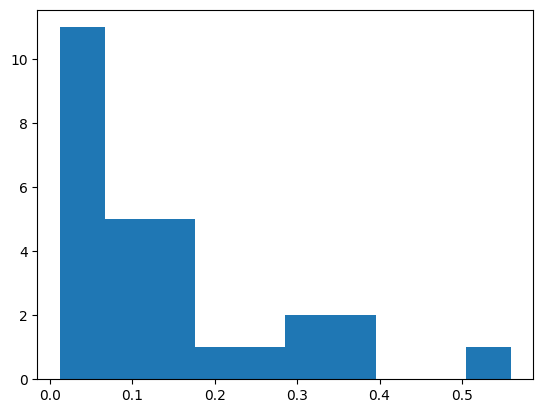

In [ ]:
time_bewteen_arrives = []
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    time_bewteen_arrives.extend(x[0] - y[0] for x, y in zip(arrive_finish_pairs[1:], arrive_finish_pairs))
pd.Series(time_bewteen_arrives).describe(), plt.hist(time_bewteen_arrives)

In [ ]:
top_batches = batches[:10]

n_overlap = 0
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    is_overlap = False
    for arrive, finish, device in arrive_finish_pairs:
        for _, b in top_batches:
            if (b['device_id'] == device) and (arrive < b['timestamp']) and (b['timestamp'] < finish):
                is_overlap = True 
    n_overlap += is_overlap
n_overlap / len(slo_violated_to_arrive_finish_pairs), n_overlap, len(slo_violated_to_arrive_finish_pairs)

TypeError: unhashable type: 'slice'

(count     136.000000
 mean     1899.404412
 std      2257.199141
 min        19.000000
 25%       389.250000
 50%       900.500000
 75%      2218.500000
 max      7436.000000
 dtype: float64,
 count     645.000000
 mean     2147.539535
 std      2003.150357
 min        11.000000
 25%       591.000000
 50%      1607.000000
 75%      2951.000000
 max      7436.000000
 dtype: float64)

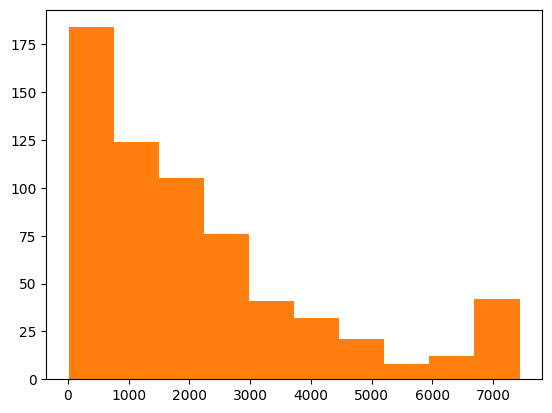

In [ ]:
violated_reqs = [req for req in req_data if req['slo_violation'] != 'none']
attained_reqs = [req for req in req_data if req['slo_violation'] == 'none']
plt.hist([req['prompt_tokens'] for req in violated_reqs])
plt.hist([req['prompt_tokens'] for req in attained_reqs])
pd.Series([req['prompt_tokens'] for req in violated_reqs]).describe(), pd.Series([req['prompt_tokens'] for req in attained_reqs]).describe()

In [ ]:
violated_reqs[5]

{'req_id': '133',
 'prompt_tokens': 6041,
 'num_cached_tokens': 0,
 'arrival_time': 196.50914692878723,
 'engine_arrival_time': 196.5216646194458,
 'profit': 0,
 'schedules': [{'batch_id': 1312,
   'num_scheduled_tokens': 320,
   'elapsed': 0.05184030532836914,
   'timestamp': 197.7040719985962,
   'device_id': 0},
  {'batch_id': 1313,
   'num_scheduled_tokens': 607,
   'elapsed': 0.05094623565673828,
   'timestamp': 197.75502228736877,
   'device_id': 0},
  {'batch_id': 1314,
   'num_scheduled_tokens': 591,
   'elapsed': 0.04977607727050781,
   'timestamp': 197.80480241775513,
   'device_id': 0},
  {'batch_id': 1315,
   'num_scheduled_tokens': 591,
   'elapsed': 0.050180912017822266,
   'timestamp': 197.85498714447021,
   'device_id': 0},
  {'batch_id': 1316,
   'num_scheduled_tokens': 594,
   'elapsed': 0.04993271827697754,
   'timestamp': 197.9049265384674,
   'device_id': 0},
  {'batch_id': 1317,
   'num_scheduled_tokens': 592,
   'elapsed': 0.04981637001037598,
   'timestamp': 197

In [ ]:
import pandas as pd 
import math
import matplotlib.pyplot as plt


In [ ]:

def plot(event_file):
    df = pd.read_json(event_file, lines=True)

    df['relative power'] = df['energy_est'] * df['load_scale']

    features = ['load_scale', 'n_device', 'ttft_slo_scale', 'slo_tpot']
    LABEL_MAP = {
        'atfc / slosserve_1_disagg_4': 'SLO Packer (Disagg)',
        'atfc / slosserve_2': 'SLO Packer (2, Colocated)',
        'atfc / slosserve_1': 'SLO Packer (1, Colocated)',
        'atfc / slosserve': 'SLO Packer (Colocated)',
        'atfc / round_robin': 'SLO Packer (Round Robin)',
        'atfc / slosserve_4': 'SLO Packer (4, Colocated)',
        'atfc / slosserve_5': 'SLO Packer (5, Colocated)',
        'sarathi+ / round_robin': 'vLLM+ (Colocated)',
        'sarathi+ / round_robin-1-disagg-4': 'vLLM + (Disagg)'
    }
    for feature in features:
        if len(df[feature].unique()) == 1:
            continue
        other_features = [f for f in features if f != feature]
        n_groups = len(df.groupby(other_features))
        ncols = min(3, n_groups)
        nrows = math.ceil(n_groups / ncols)
        for ylabel in ['relative power', 'slo_violation_rate']:
            fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
            idx = 0
            for other_feature_values, group in df.groupby(other_features):
                row, col = divmod(idx, ncols)
                ax = axes[row][col]
                idx += 1
                for (sched, route), group in group.groupby(['scheduling_policy', 'routing_policy']):
                    group_sorted = group.sort_values(feature)
                    label = f"{sched} / {route}"
                    label = LABEL_MAP[label]
                    ax.plot(group_sorted[feature], group_sorted[ylabel], marker='o', label=label)
                other_features_dict = {f: v for f, v in zip(other_features, other_feature_values)}
                ax.set_xlabel(feature)
                ax.set_ylabel(ylabel)
                # ax.set_title(f'{ylabel} vs {feature}\n({other_features_dict})')
                ax.legend()
            fig.tight_layout()
            # fig.savefig(f'{experiment_dir}/figs/{ylabel}_vs_{feature}.png', dpi=300)
            # print(f"Saved plot to {experiment_dir}/figs/{ylabel}_vs_{feature}.png")
    return df

   scheduling_policy     routing_policy
0               atfc  slosserve_planner
1               atfc  slosserve_planner
2               atfc  slosserve_planner
3               atfc  slosserve_planner
4               atfc        round_robin
5               atfc        round_robin
6               atfc        round_robin
7               atfc        round_robin
8           sarathi+        round_robin
9           sarathi+        round_robin
10          sarathi+        round_robin
11          sarathi+        round_robin


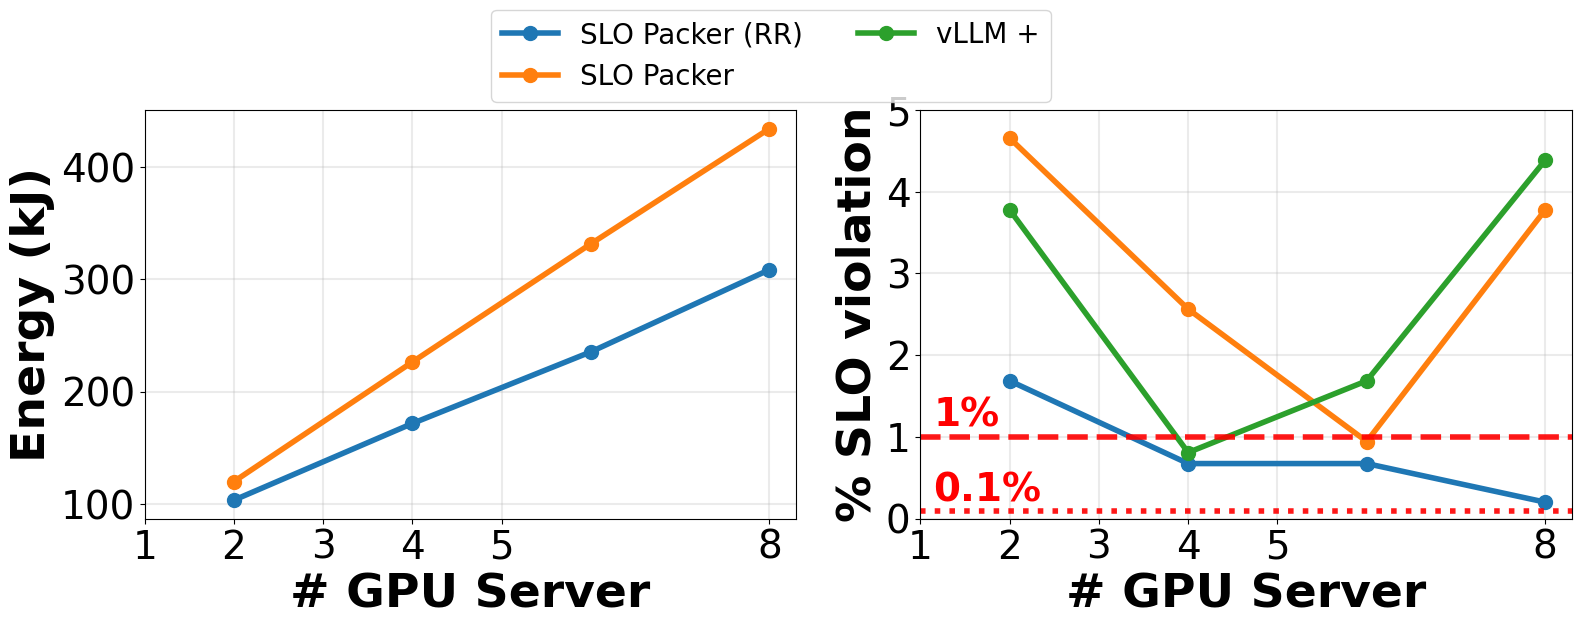

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json(
    'experiments_emulation_0313/Qwen-7B_constant_sharegpt_code:azure_code_23_t0:600_arrival_0.0/results.jsonl',
    lines=True
)
df['relative power'] = df['energy_est'] * df['load_scale'] / 1000
group = df[df['load_scale'] == 1.0]
print(group[['scheduling_policy', 'routing_policy']])

LABEL_MAP = {
    'atfc / slosserve_planner': 'SLO Packer',
    'atfc / round_robin': 'SLO Packer (RR)',
    'sarathi+ / round_robin': 'vLLM +',
}

feature = 'n_device'
keep_labels = {'SLO Packer', 'vLLM +'}

# Slide-friendly typography
plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 34,
    "axes.titlesize": 34,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 26,   # make legend bigger since it's outside
    "lines.linewidth": 4.0,
    "lines.markersize": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # a bit wider for outside legend

# ---- Left: SLO violation ----
ax0 = axes[1]
handles = []
labels = []

for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    # if label not in keep_labels:
    #     continue

    sub_sorted = sub.sort_values(feature)
    (line,) = ax0.plot(sub_sorted[feature], sub_sorted['slo_violation_rate'] * 100,
                       marker='o', label=label)

    # collect handles for shared legend (only once per label)
    if label not in labels:
        handles.append(line)
        labels.append(label)

# Red threshold lines (no text)
ax0.axhline(1.0, linestyle='--', linewidth=4.0, color='red', alpha=0.9)
ax0.axhline(0.1, linestyle=':',  linewidth=4.0, color='red', alpha=0.9)

ax0.set_ylabel('% SLO violation', fontweight='bold')
ax0.set_xlabel('# GPU Server', fontweight='bold')
ax0.set_ylim(0, 5)
ax0.grid(True, alpha=0.25, linewidth=1.5)

# ---- Right: Energy ----
ax1 = axes[0]
for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    if label not in keep_labels:
        continue

    sub_sorted = sub.sort_values(feature)
    ax1.plot(sub_sorted[feature], sub_sorted['relative power'], marker='o', label=label)

ax1.set_ylabel('Energy (kJ)', fontweight='bold')
ax1.set_xlabel('# GPU Server', fontweight='bold')
ax1.grid(True, alpha=0.25, linewidth=1.5)

xticks = [1, 2, 3, 4, 5, 8]
for ax in axes:
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])


# ---- Shared legend outside (right) ----
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.4, 1.10),
    ncol=2,              # set 1/2/3 depending on how wide you want it
    frameon=True,
    fontsize = 20
)


x_left, x_right = ax0.get_xlim()
x_text = x_left + 0.02 * (x_right - x_left)

ax0.text(x_text, 1.0 * 1.03,  "1%",   color="red",
         fontsize=28, fontweight="bold", va="bottom", ha="left")
ax0.text(x_text, 0.1 * 1.10,  "0.1%", color="red",
         fontsize=28, fontweight="bold", va="bottom", ha="left")

# leave room on the right for legend
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

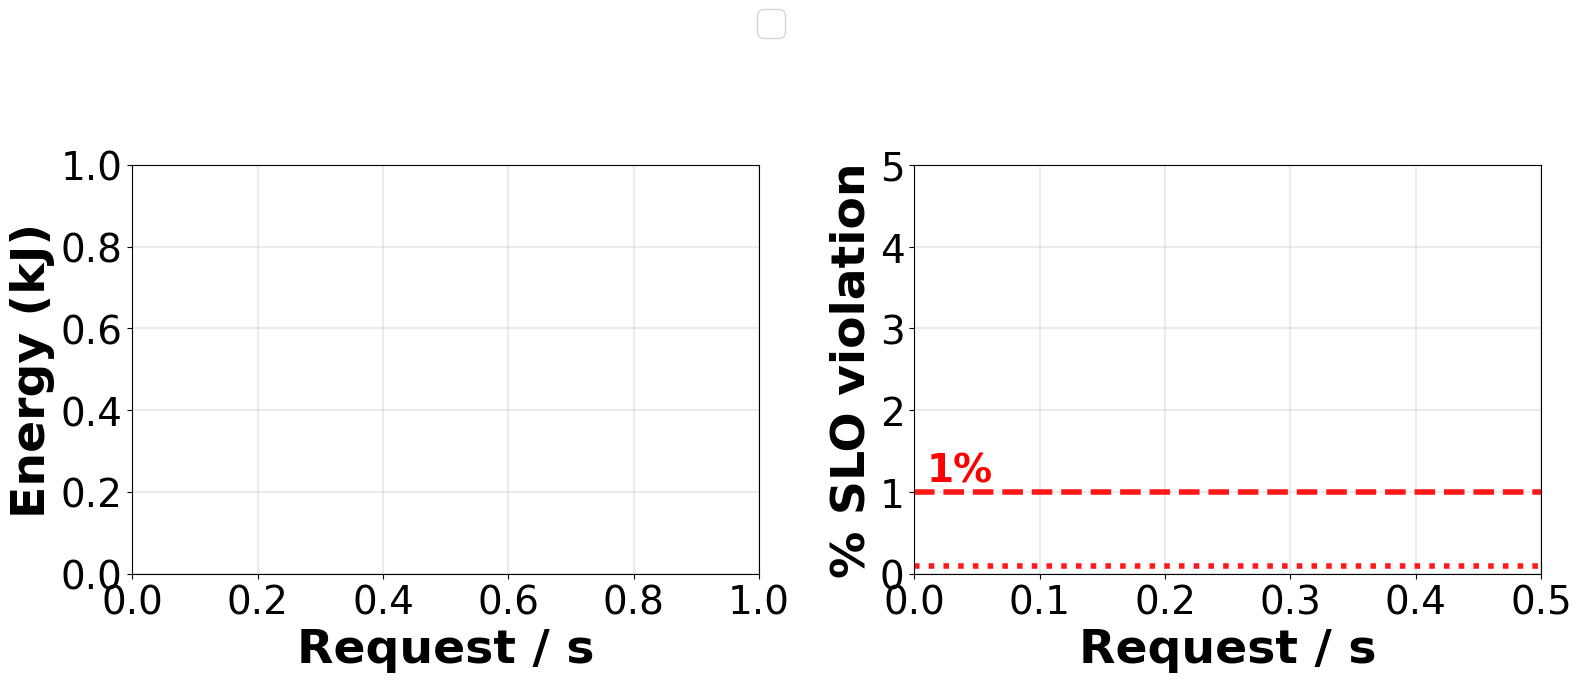

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json(
    'experiments_emulation_new/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/results.jsonl',
    lines=True
)
df['relative power'] = df['energy_est'] * df['load_scale'] / 1000
group = df[df['n_device'] == 8]

LABEL_MAP = {
    'atfc / slosserve_1_disagg_4': 'SLO Packer (Disagg)',
    'atfc / slosserve_2': 'SLO Packer (Colocated)',
    'atfc / slosserve_1': 'SLO Packer (1, Colocated)',
    'atfc / slosserve': 'SLO Packer (2, Colocated)',
    'atfc / round_robin': 'SLO Packer (Round Robin)',
    'atfc / slosserve_4': 'SLO Packer (4, Colocated)',
    'atfc / slosserve_5': 'SLO Packer (5, Colocated)',
    'sarathi+ / round_robin': 'vLLM+ (Colocated)',
    'sarathi+ / round_robin-1-disagg-4': 'vLLM+ (Disagg)'
}

feature = 'load_scale'
keep_labels = {'SLO Packer (Colocated)', 'SLO Packer (Disagg)', 'vLLM+ (Colocated)', 'vLLM+ (Disagg)'}

# Slide-friendly typography
plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 34,
    "axes.titlesize": 34,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 26,   # make legend bigger since it's outside
    "lines.linewidth": 4.0,
    "lines.markersize": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # a bit wider for outside legend

# ---- Left: SLO violation ----
ax0 = axes[1]
handles = []
labels = []

for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    if label not in keep_labels:
        continue

    sub_sorted = sub.sort_values(feature)
    (line,) = ax0.plot(sub_sorted[feature], sub_sorted['slo_violation_rate'] * 100,
                       marker='o', label=label)

    # collect handles for shared legend (only once per label)
    if label not in labels:
        handles.append(line)
        labels.append(label)

# Red threshold lines (no text)
ax0.axhline(1.0, linestyle='--', linewidth=4.0, color='red', alpha=0.9)
ax0.axhline(0.1, linestyle=':',  linewidth=4.0, color='red', alpha=0.9)

ax0.set_ylabel('% SLO violation', fontweight='bold')
ax0.set_xlabel('Request / s', fontweight='bold')
ax0.set_ylim(0, 5)
ax0.set_xlim(0, 2.0)
ax0.grid(True, alpha=0.25, linewidth=1.5)

# ---- Right: Energy ----
ax1 = axes[0]
for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    if label not in keep_labels:
        continue

    sub_sorted = sub.sort_values(feature)
    ax1.plot(sub_sorted[feature], sub_sorted['relative power'], marker='o', label=label)

ax1.set_ylabel('Energy (kJ)', fontweight='bold')
ax1.set_xlabel('Request / s', fontweight='bold')
ax1.grid(True, alpha=0.25, linewidth=1.5)

# ---- Shared legend outside (right) ----
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.4, 1.20),
    ncol=2,              # set 1/2/3 depending on how wide you want it
    frameon=True
)

ax0.set_xlim(0, 0.5)

x_left, x_right = ax0.get_xlim()
x_text = x_left + 0.02 * (x_right - x_left)

ax0.text(x_text, 1.0 * 1.03,  "1%",   color="red",
         fontsize=28, fontweight="bold", va="bottom", ha="left")
# ax0.text(x_text, 0.1 * 1.10,  "0.1%", color="red",
#          fontsize=28, fontweight="bold", va="bottom", ha="left")

# leave room on the right for legend
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [ ]:
df = plot('experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/results.jsonl')

# plot('experiments_emulation/Qwen-7B_constant_azure_chat_23:azure_chat_23_t0:600_arrival_0.0/results.jsonl')

/tmp/ipykernel_2181645/3328572535.py:2: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(event_file, lines=True)


ValueError: Expected object or value

,load_scale,rps,n_device,scheduling_policy,routing_policy,profit,ttft_slo_scale,slo_tpot,slo_violation_rate,perf_model_err,...,1_active (%),0_active (%),3_active (%),4_active (%),5_active (%),2_active (%),6_active (%),7_active (%),8_active (%),relative power
0,1,4.778562,8,sarathi+,round_robin,0,5,0.05,0.002790,1,...,0.004285,0.003626,0.004944,0.011206,0.017139,0.000989,0.044825,0.163151,0.749835,688179.70
1,1,4.778562,8,atfc,slosserve_2,0,5,0.05,0.002442,1,...,0.005265,0.002632,0.136887,0.040145,0.014808,0.798618,0.001645,NaN,NaN,393421.45
2,2,9.557123,8,sarathi+,round_robin,0,5,0.05,0.012208,1,...,0.009753,NaN,0.001951,0.002601,0.001951,0.001300,0.006502,0.019506,0.956437,707746.70
3,2,9.557123,8,atfc,slosserve_2,0,5,0.05,0.026857,1,...,0.013436,NaN,0.051823,0.311580,0.397953,0.071017,0.132438,0.021753,NaN,540909.10
4,1,4.778562,8,atfc,slosserve_1_disagg_4,0,5,0.05,0.004883,1,...,0.016776,0.003618,0.034539,0.277303,0.454934,0.017763,0.158553,0.030921,0.005592,573333.10
5,3,14.335685,8,sarathi+,round_robin,0,5,0.05,0.069062,1,...,0.010506,NaN,0.002865,0.001910,0.004776,0.000955,0.000955,0.004776,0.973257,729901.95
6,3,14.335685,8,atfc,slosserve_2,0,5,0.05,0.551099,1,...,0.026774,NaN,0.009371,0.036814,0.030790,0.046854,0.012718,0.836680,NaN,932442.15
7,4,19.114246,8,atfc,slosserve_2,0,5,0.05,0.937217,1,...,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,425847.20
8,2,9.557123,8,atfc,slosserve_1_disagg_4,0,5,0.05,0.633066,1,...,0.194502,0.106206,0.056227,0.097043,0.275718,0.118701,0.107039,0.031237,0.013328,798150.60
9,1,4.778562,8,sarathi+,round_robin-1-disagg-4,0,5,0.05,0.008720,1,...,0.004283,0.003624,0.012521,0.211203,0.317298,0.002306,0.233278,0.139044,0.076442,669972.40


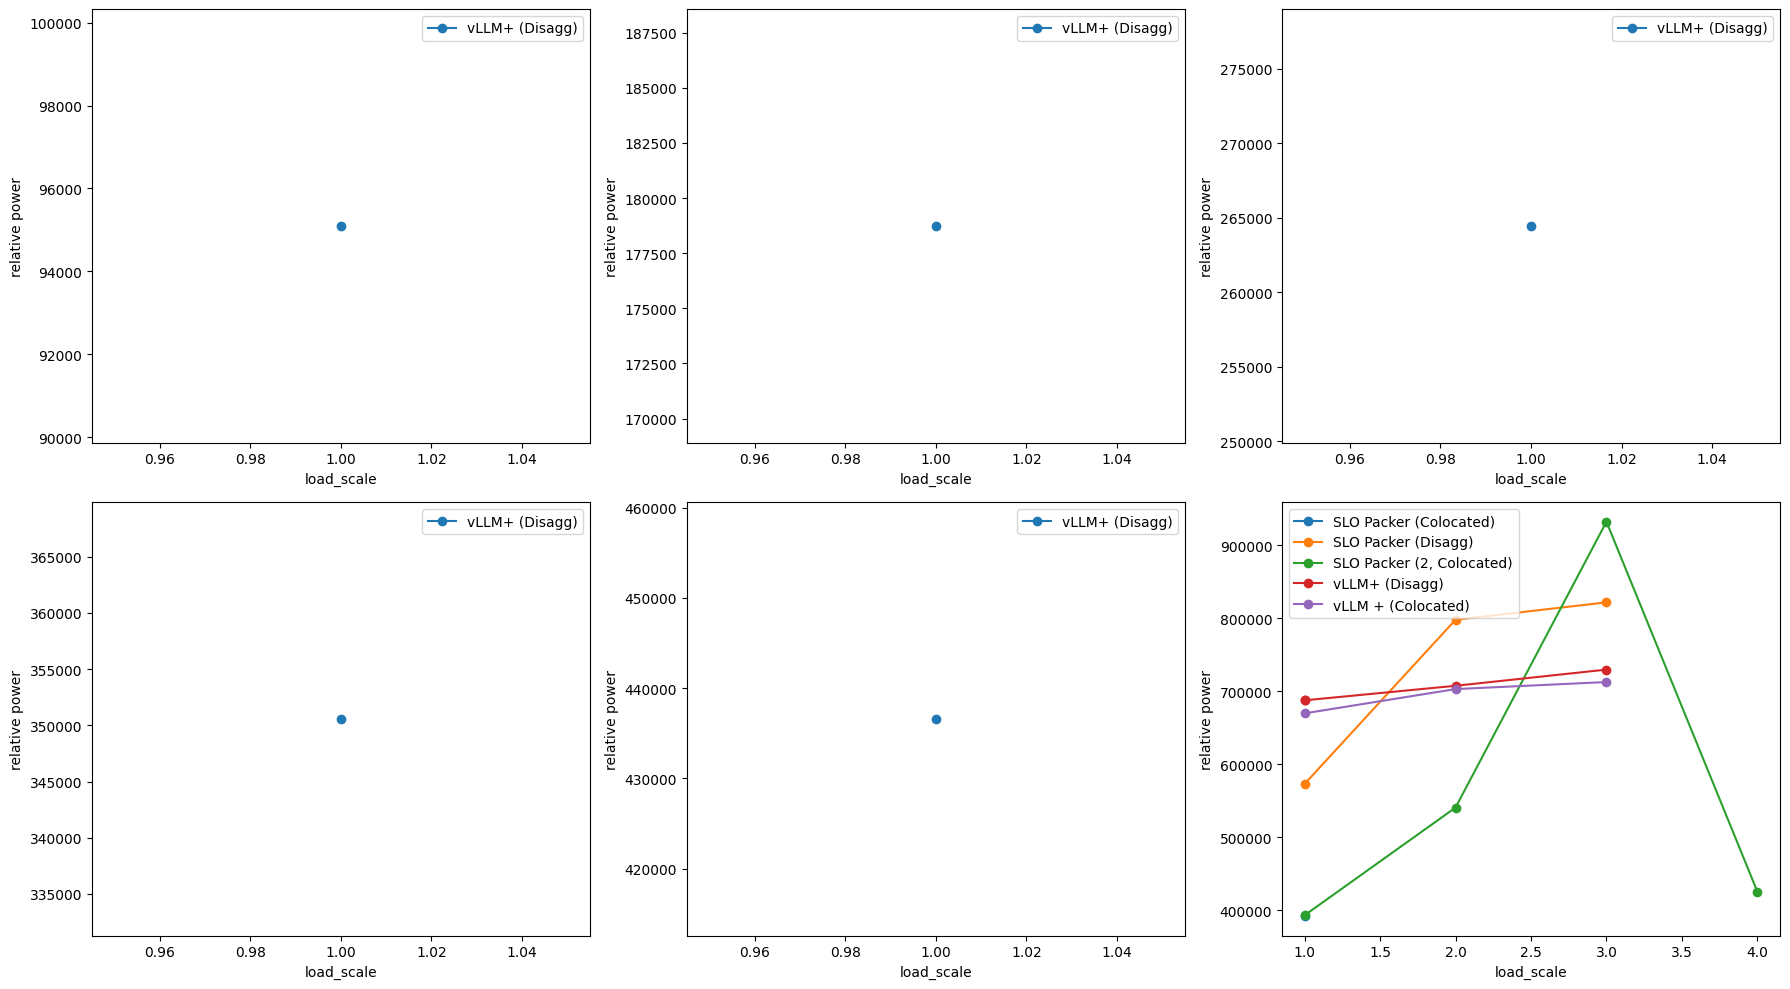

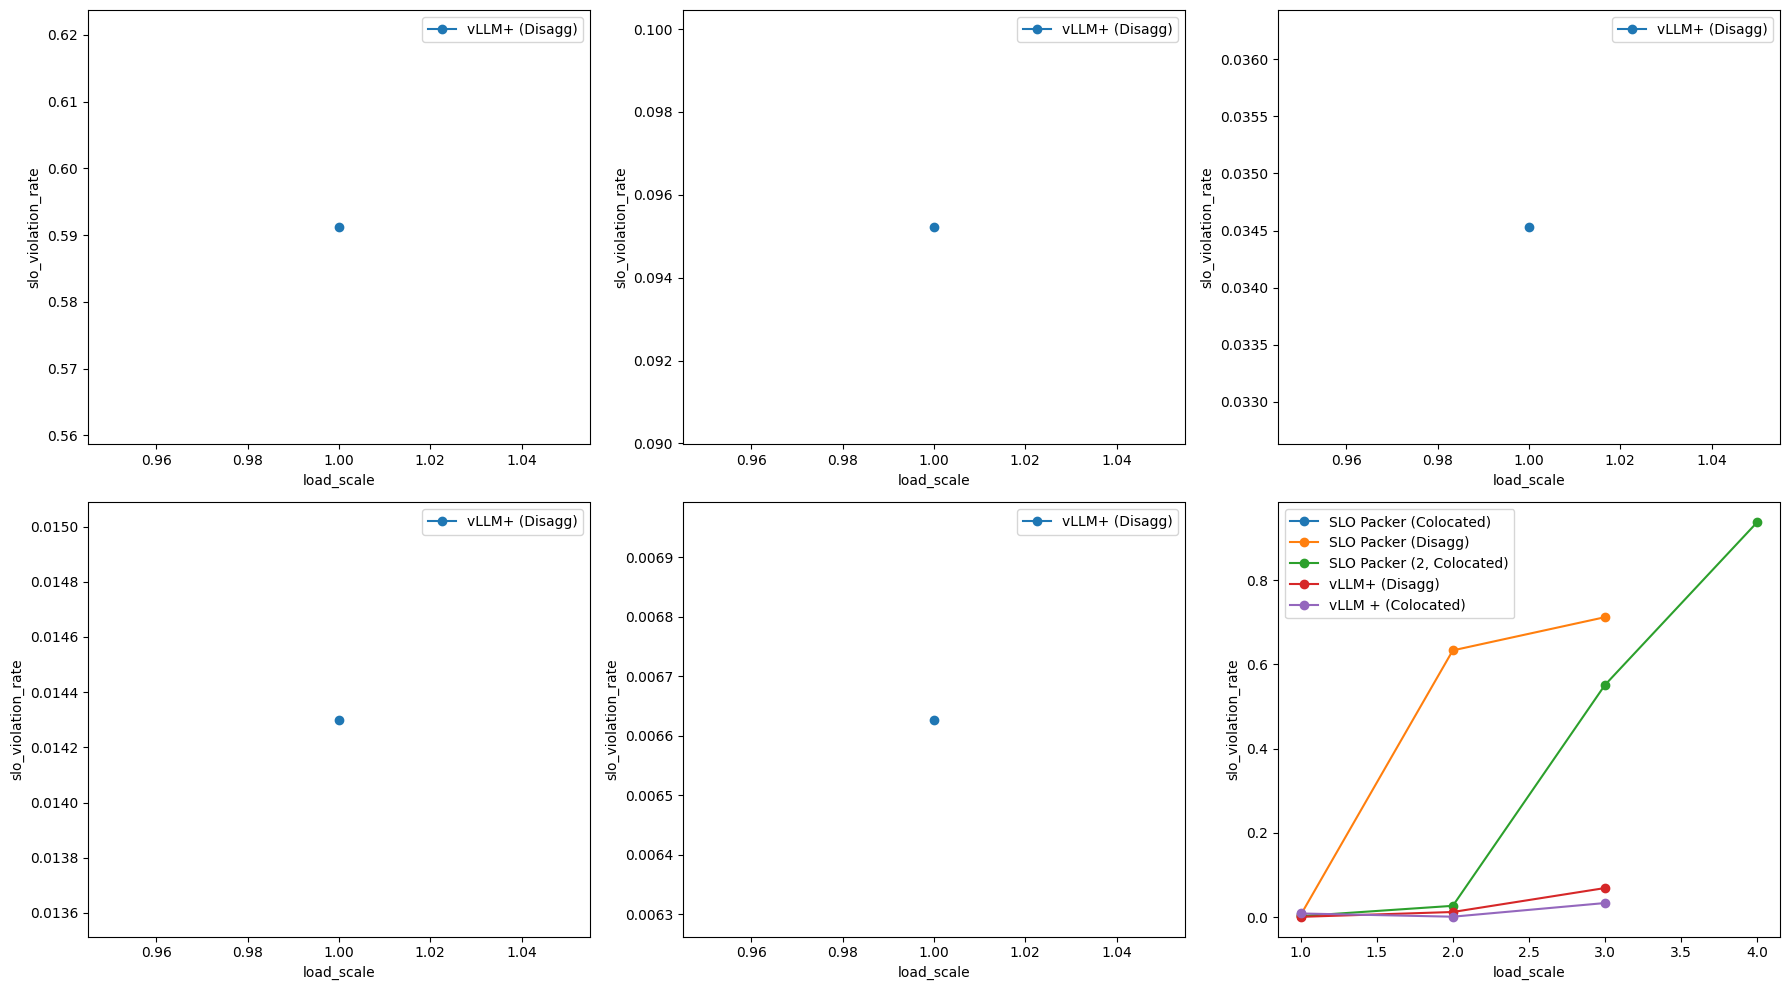

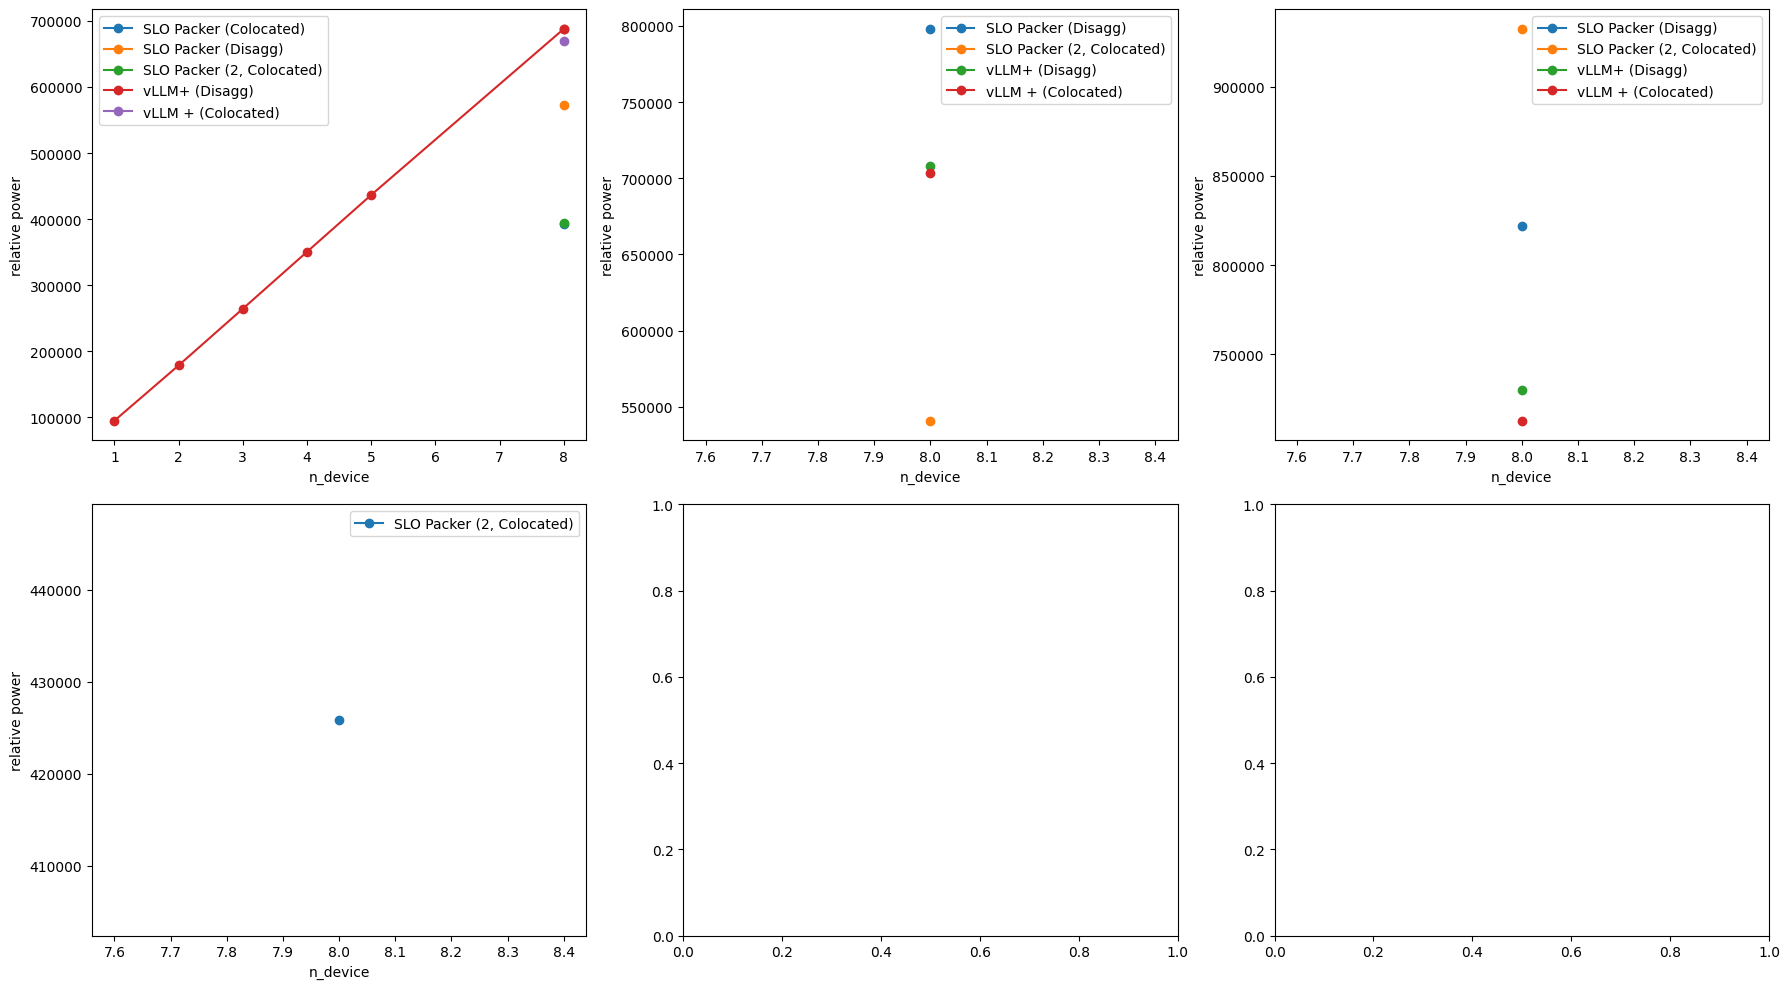

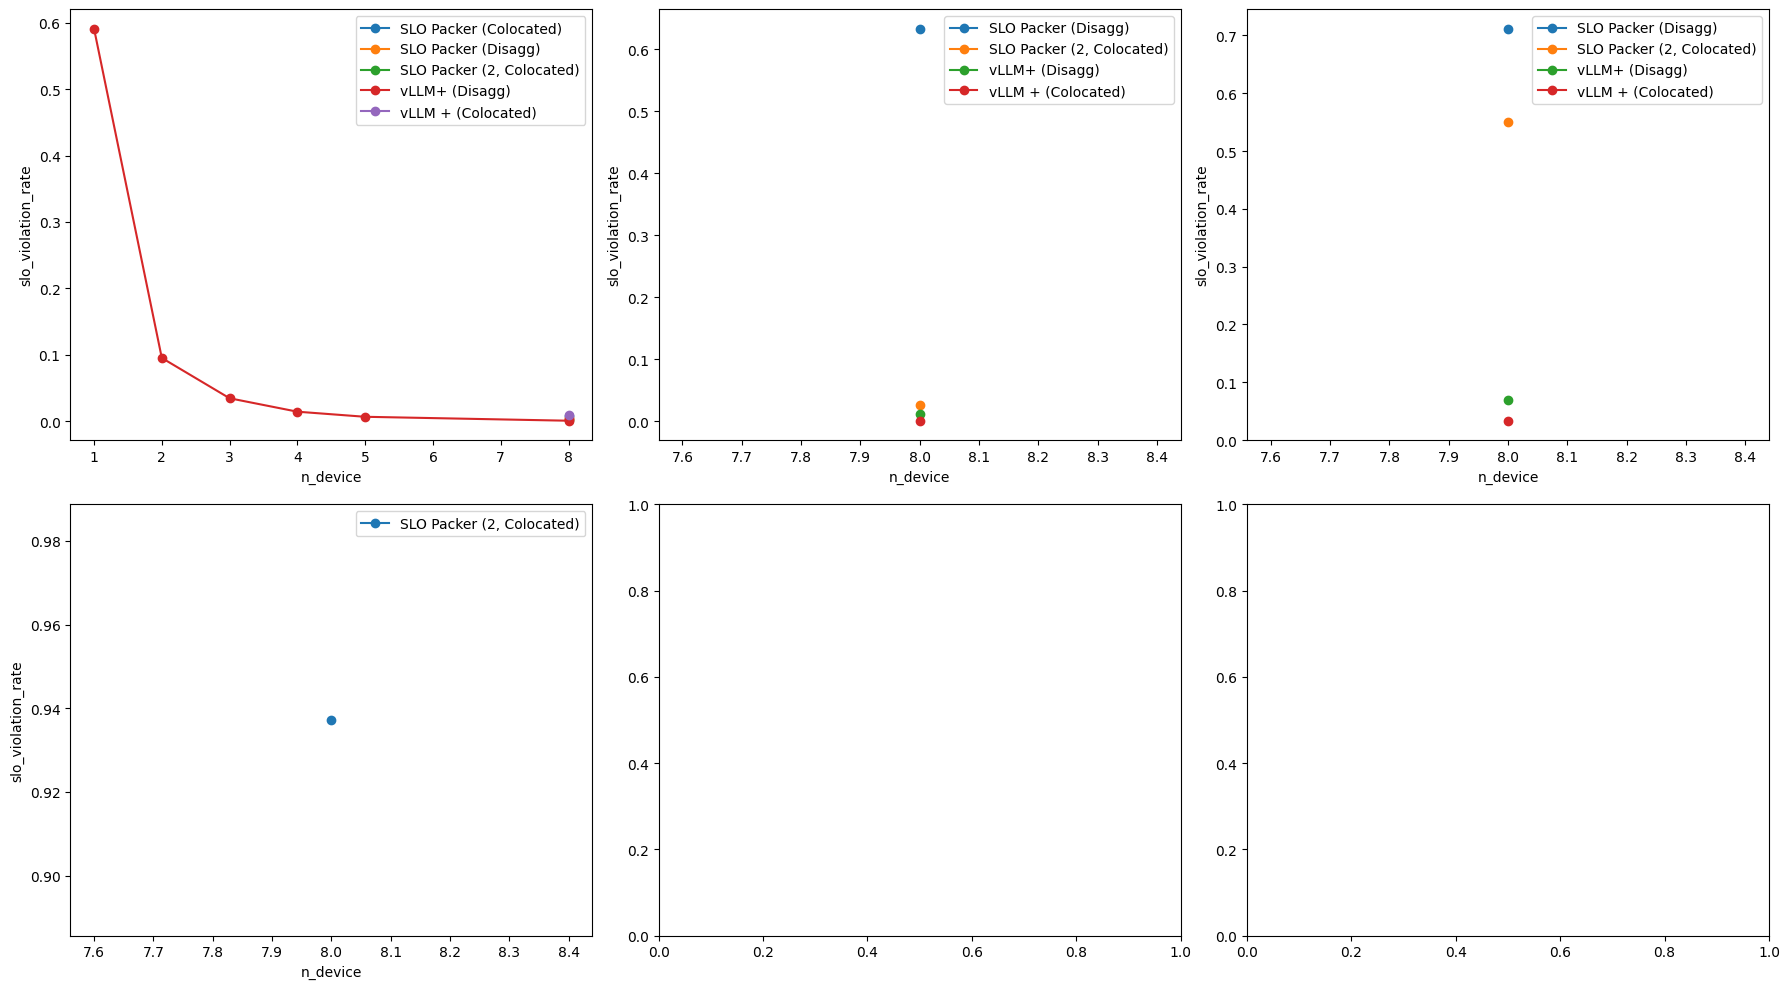

In [ ]:
plot('experiments_emulation/Qwen-7B_constant_azure_chat_23:azure_chat_23_t0:600_arrival_0.0/results.jsonl')

In [ ]:
subdf = df[df['load_scale'] == 0.5]
subdf['event_file'].tolist()

['experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin_0.5_8_arrival_5.0_0.05_asap.events.jsonl',
 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_2_0.5_8_arrival_5.0_0.05_asap.events.jsonl',
 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_1_disagg_4_0.5_8_arrival_5.0_0.05_asap.events.jsonl',
 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin-1-disagg-4_0.5_8_arrival_5.0_0.05_asap.events.jsonl']

In [ ]:
from motivation.events_analysis import draw_energy_comparison


vLLM+ (Colocated) average  1.4357446808510639 devices
SLO Packer (Colocated) average  0.8509369676320273 devices
SLO Packer (Disagg) average  1.1665250637213254 devices
vLLM+ (Disagg) average  1.6652470187393527 devices
all_energies {'vLLM+ (Colocated)': np.float64(554.0296170212766), 'SLO Packer (Colocated)': np.float64(501.3839011925042), 'SLO Packer (Disagg)': np.float64(529.7535683942226), 'vLLM+ (Disagg)': np.float64(574.7037052810903)}
saved to energy_comparison-None.png
saved to energy_distr-None.png


TypeError: cannot unpack non-iterable NoneType object

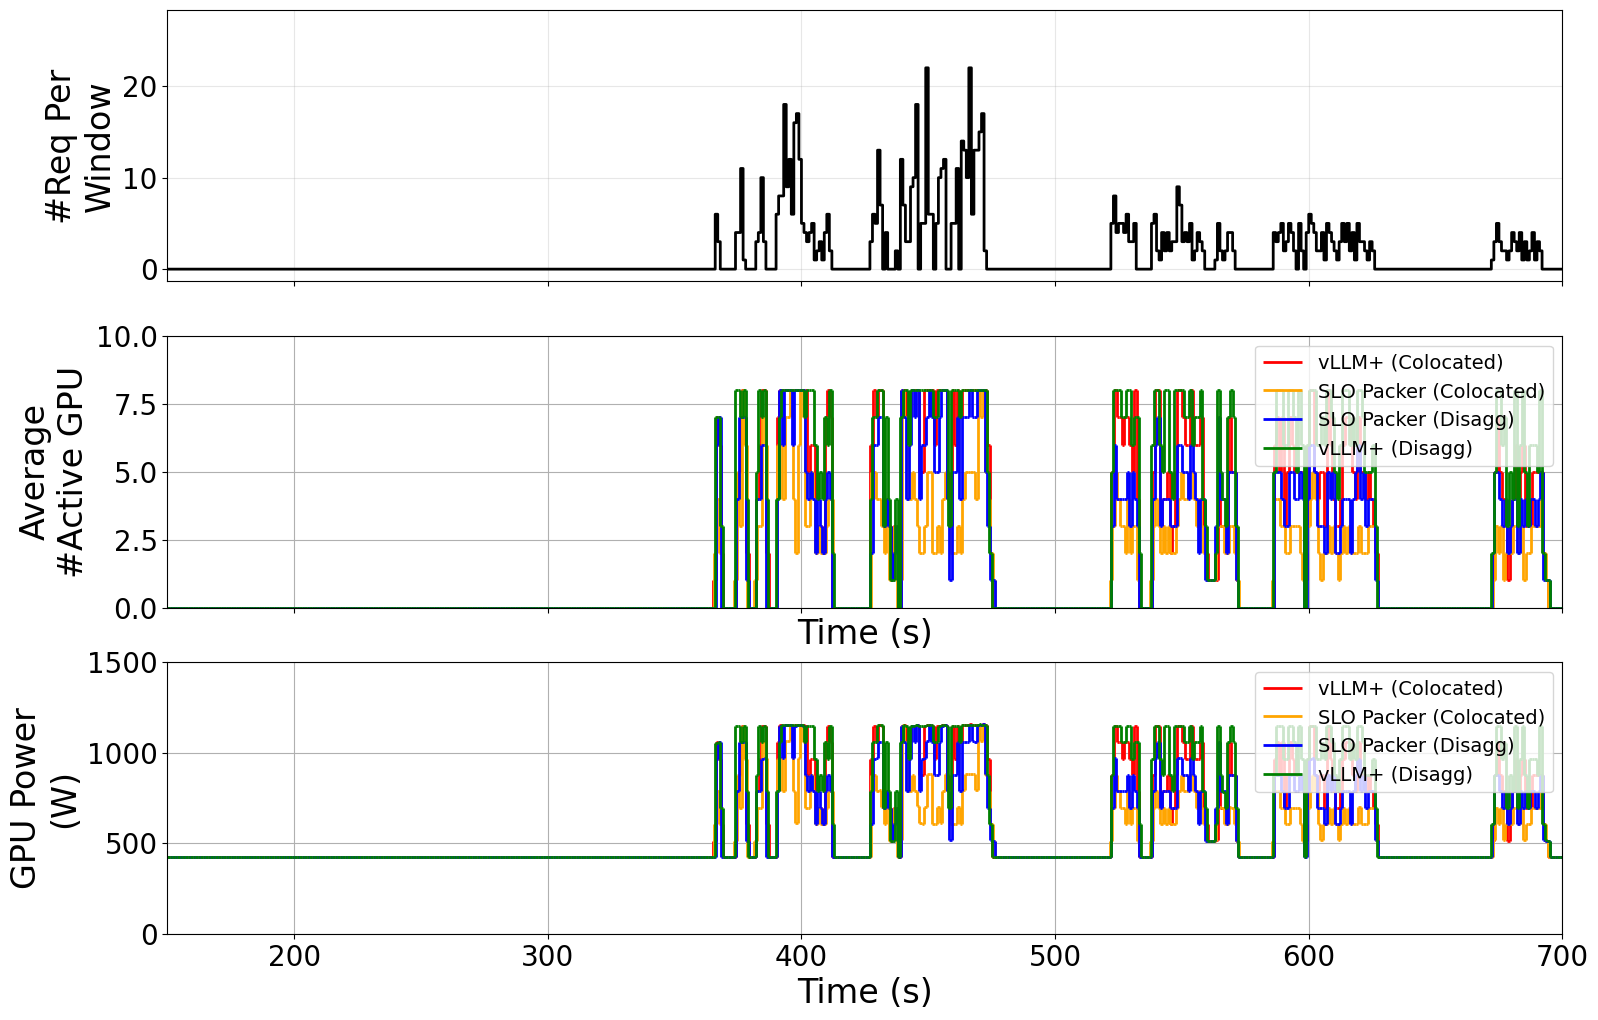

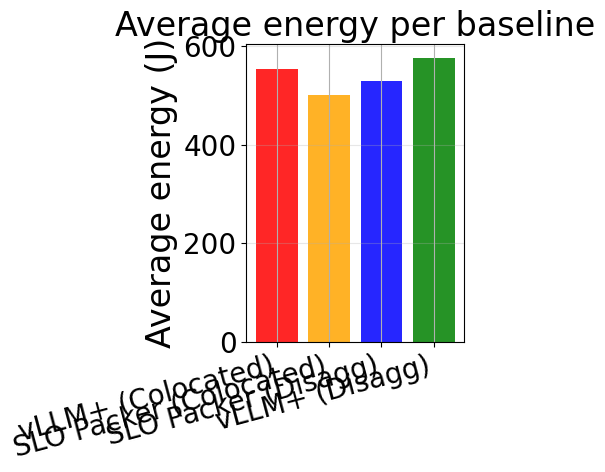

In [ ]:

fig, axes = draw_energy_comparison(
    event_files = [('vLLM+ (Colocated)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'red'),
                ('SLO Packer (Colocated)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_2_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'orange'),
 ('SLO Packer (Disagg)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_1_disagg_4_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'blue'),
 ('vLLM+ (Disagg)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin-1-disagg-4_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'green')],
    # [
    #     ('Baseline (8 Servers)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/vllm_round_robin_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'red'),
    #     # ('Baseline (8 Servers)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4600_anytime_0.0/sarathi_round_robin_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'orange'),
    #     # ('RR + SLOsServe (4, 100%)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_round_robin_1.0_4_anytime_5.0_0.05.events.jsonl', 4, 'orange'),
    #     # ('LC (w/o Pre. Adm.) + SLOsServe  (8, 70.8%)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'green'),
    #     # ('LC (Pre. Adm) + SLOsServe  (8, 93.8%)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-0.05_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'green'),
    #     ('SLOsServe (4 Servers)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4600_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_4_anytime_5.0_0.05.events.jsonl', 4, 'blue')
    # ],
    output_suffix = None
)
for ax in axes:
    axes[0].set_xlim(350, 650)

In [ ]:
df = pd.read_json('experiments_emulation/Qwen-7B_constant_azure_chat_23:azure_chat_23_t0:600_arrival_0.0/results.jsonl', lines=  True)
df

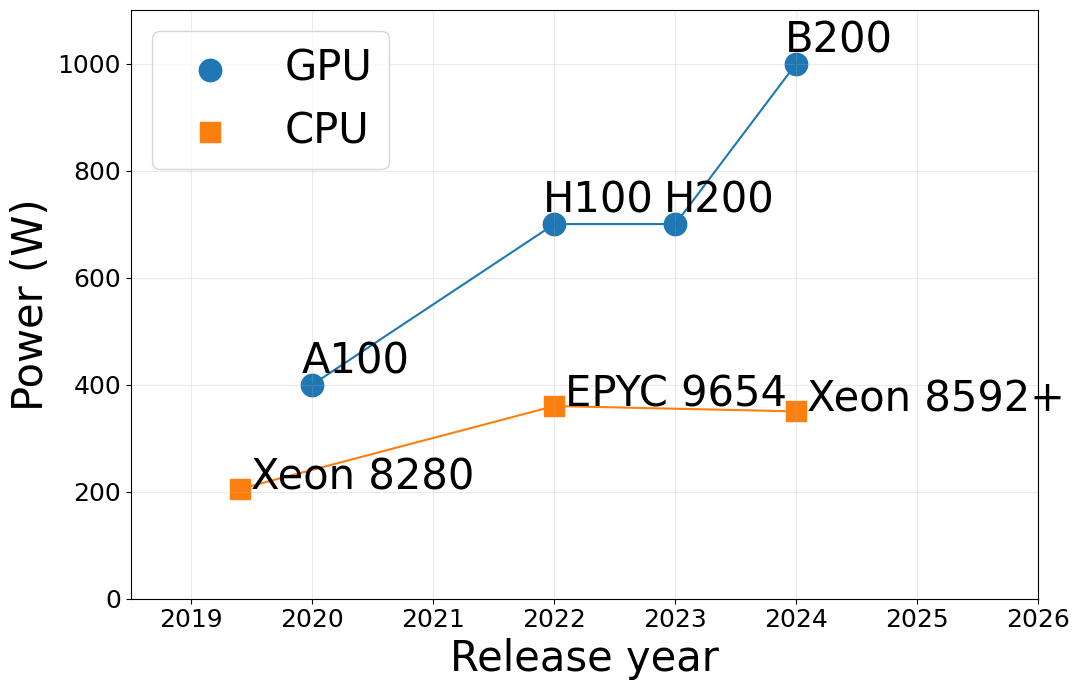

In [ ]:
import matplotlib.pyplot as plt

# Data (TDP/TGP in Watts) + release year
gpus = [
    ("A100", 2020, 400),
    ("H100", 2022, 700),
    ("H200", 2023, 700),
    ("B200", 2024, 1000),
]

cpus = [
    # ("Xeon 8180", 2017, 205),
    ("Xeon 8280", 2019.4, 205),
    ("EPYC 9654", 2022, 360),
    # ("Xeon 8490H", 2023, 350),
    ("Xeon 8592+", 2024, 350),  # Q4'23 ~ 2023.8 for spacing
]

# Split for plotting
gpu_years = [y for _, y, _ in gpus]
gpu_watts = [w for _, _, w in gpus]

cpu_years = [y for _, y, _ in cpus]
cpu_watts = [w for _, _, w in cpus]

plt.figure(figsize=(11, 7))
plt.scatter(gpu_years, gpu_watts, s=260, marker='o', label="GPU")
plt.scatter(cpu_years, cpu_watts, s=220, marker='s', label="CPU")

# Connect points to show "growth" trend (sorted by year)
g_sorted = sorted(zip(gpu_years, gpu_watts))
c_sorted = sorted(zip(cpu_years, cpu_watts))
plt.plot([x for x,_ in g_sorted], [y for _,y in g_sorted])
plt.plot([x for x,_ in c_sorted], [y for _,y in c_sorted])

# Annotations
for name, year, watts in gpus:
    plt.annotate(f"{name}", (year, watts),
                 textcoords="offset points", xytext=(-8, 8), ha='left', fontsize=30)
for name, year, watts in cpus:
    plt.annotate(f"{name}", (year, watts),
                 textcoords="offset points", xytext=(8, 0), ha='left', fontsize=30)

plt.xlabel("Release year", fontsize=30)
plt.ylabel("Power (W)", fontsize=30)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(2018.5, 2026)
plt.ylim(0, 1100)
plt.legend(fontsize=30, loc="upper left")
plt.grid(True, alpha=0.25)

plt.tight_layout()

# out_png = "/mnt/data/power_vs_time_gpu_cpu.png"
# out_pdf = "/mnt/data/power_vs_time_gpu_cpu.pdf"
# plt.savefig(out_png, dpi=200, bbox_inches="tight")
# plt.savefig(out_pdf, bbox_inches="tight")
# out_png, out_pdf


The Avg2Peak for different workloads 


We want to characterize the headroom for different loads under different settings;

Graph1: for each workload pair, under 2/10/30 window, measure the avg2peak for disaggrated setting and aggregated setting 

Graph2: for each workload pair, under 2/10/30 window, measure the peak2min for disaggrated setting and aggregated setting 

Graph3: for each workload pair, under 2/10/30 window, measure the n_total for disaggrated setting and aggregated setting 

In [ ]:
import pandas as pd 
df = pd.read_csv('headroom_outputs/headroom.csv')

In [ ]:
df

,dataset,is_oracle,is_pd_disagg,window_minutes,window_start,window_end,avg2peak,peak2min,n_avg_active,n_total,...,il_p95,il_median,ol_mean,ol_max,ol_p95,ol_median,fail_comp,fail_mem,fail_oom,fail_total
0,azure_chat_23:azure_chat_23,False,False,5,0.0,300.0,0.498351,7.0,3.488454,7,...,3679.60,1027.0,247.600000,1000.0,471.80,181.0,2894,0,0,2894
1,azure_chat_23:azure_chat_23,False,False,5,300.0,600.0,0.458461,5.0,2.292305,5,...,4083.00,998.5,199.732771,1000.0,438.00,123.0,1649,0,0,1649
2,azure_chat_23:azure_chat_23,False,False,5,600.0,900.0,0.421164,9.0,3.790474,9,...,4083.20,1027.0,205.280026,669.0,455.60,119.0,4436,0,0,4436
3,azure_chat_23:azure_chat_23,False,False,5,900.0,1200.0,0.453957,6.0,2.723742,6,...,4080.00,997.0,200.246637,939.0,445.00,124.0,1810,0,0,1810
4,azure_chat_23:azure_chat_23,False,False,5,1200.0,1500.0,0.426718,17.0,7.254209,17,...,4084.00,1028.0,218.837580,992.0,460.00,138.0,12769,0,0,12769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,azure_code_23:sharegpt_code,True,True,5,1500.0,1800.0,0.350435,3.0,1.051306,3,...,252.60,63.0,375.046243,862.0,654.60,353.0,1,0,0,1
256,azure_code_23:sharegpt_code,True,True,10,0.0,600.0,0.374511,4.0,1.498045,4,...,319.00,65.0,368.898111,1322.0,678.80,347.0,1186,0,0,1186
257,azure_code_23:sharegpt_code,True,True,10,600.0,1200.0,0.475675,7.0,3.329727,7,...,328.25,65.0,367.313607,1405.0,666.00,349.5,5265,0,0,5265
258,azure_code_23:sharegpt_code,True,True,10,1200.0,1800.0,0.290560,4.0,1.162238,4,...,308.00,62.0,372.352770,1227.0,679.00,351.0,587,0,0,587


In [ ]:
# TODO: The Avg2Peak for different workloads 
# We want to characterize the headroom for different loads under different settings;

# Graph1: for each workload pair, under 5/10/30 window, measure the avg2peak (w/ std) for disaggrated setting and aggregated setting 

# Graph2: for each workload pair, under 5/10/30 window, measure the peak2min (w/ std) for disaggrated setting and aggregated setting 

# Graph3: for each workload pair, under 5/10/30 window, measure the n_total (w/ std) for disaggrated setting and aggregated setting 